In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
exp2_emp_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/EXPERIMENT2emp_ptft_curves.csv')
exp3_emp_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/EXPERIMENT3emp_ptft_curves.csv')

exp2_replica_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/EXPERIMENT2replica_ptft_curves.csv')
exp3_replica_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/EXPERIMENT3replica_ptft_curves.csv')

exp1_emp_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/EXPERIMENT1emp_ptft_curves.csv')
exp1_replica_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/EXPERIMENT1replica_ptft_curves.csv')

remaining_emp_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/REMAININGEXPERIMENTS_emp_ptft_curves.csv')
remaining_replica_df = pd.read_csv('/home/na658/multi-task2/experiments/diagonal/replica/REMAININGEXPERIMENTS_replica_ptft_curves.csv')


In [4]:
import pandas as pd

# Add experiment label before concatenation (CRITICAL for sanity later)
emp_dfs = [
    exp1_emp_df.assign(experiment="exp1"),
    exp2_emp_df.assign(experiment="exp2"),
    exp3_emp_df.assign(experiment="exp3"),
    remaining_emp_df.assign(experiment="remaining"),
]

emp_all_df = pd.concat(emp_dfs, ignore_index=True)
emp_all_df.to_csv('emp_all_df.csv', index=False)

print("Empirical merged shape:", emp_all_df.shape)
print("Empirical experiments:", emp_all_df["experiment"].unique())

Empirical merged shape: (14959, 45)
Empirical experiments: ['exp1' 'exp2' 'exp3' 'remaining']


In [5]:
rep_dfs = [
    exp1_replica_df.assign(experiment="exp1"),
    exp2_replica_df.assign(experiment="exp2"),
    exp3_replica_df.assign(experiment="exp3"),
    remaining_replica_df.assign(experiment="remaining"),
]

rep_all_df = pd.concat(rep_dfs, ignore_index=True)

rep_all_df.to_csv('rep_all_df.csv', index=False)

print("Replica merged shape:", rep_all_df.shape)
print("Replica experiments:", rep_all_df["experiment"].unique())

Replica merged shape: (6880, 22)
Replica experiments: ['exp1' 'exp2' 'exp3' 'remaining']


In [50]:
exp3_replica_df

,rho_pt,rho_ft,omega,c_pt,lambda_pt,gamma_reinit,seed,ft_teacher_norm,alpha,mse_best,...,mse_fwd,mse_bwd,diff_db,fp_residual,mse_se,mse_rel_se,mse_se_db,reliability_score_db,rho_pt_emp,rho_ft_emp
0,0.1,0.01,0.0,0.001,0.00000,0.0,0,unit_total_var,0.010000,1.073347,...,1.073347,1.073347,7.922420e-10,8.595149e-07,6.628415e-02,0.061755,0.268197,0.766208,0.101888,0.009675
1,0.1,0.01,0.0,0.001,0.00000,0.0,0,unit_total_var,0.016203,1.148459,...,1.148459,1.148459,4.186217e-08,8.429675e-07,6.641154e-02,0.057827,0.251138,0.766208,0.101888,0.009675
2,0.1,0.01,0.0,0.001,0.00000,0.0,0,unit_total_var,0.022405,1.226947,...,1.226947,1.226947,2.990467e-08,9.361870e-07,6.587984e-02,0.053694,0.233191,0.766208,0.101888,0.009675
3,0.1,0.01,0.0,0.001,0.00000,0.0,0,unit_total_var,0.028608,1.297990,...,1.297990,1.297990,1.818573e-08,9.257915e-07,6.370841e-02,0.049082,0.213162,0.766208,0.101888,0.009675
4,0.1,0.01,0.0,0.001,0.00000,0.0,0,unit_total_var,0.034810,1.347324,...,1.347324,1.347324,3.738141e-07,8.519945e-07,6.013755e-02,0.044635,0.193846,0.766208,0.101888,0.009675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,0.1,0.04,1.0,0.001,0.00099,0.0,0,unit_total_var,0.475190,0.000006,...,0.000006,0.000006,7.183342e-03,9.352801e-07,8.360553e-08,0.013852,0.060160,0.298285,0.101325,0.038350
2556,0.1,0.04,1.0,0.001,0.00099,0.0,0,unit_total_var,0.481392,0.000006,...,0.000006,0.000006,7.273186e-03,9.141922e-07,7.864140e-08,0.013715,0.059562,0.298285,0.101325,0.038350
2557,0.1,0.04,1.0,0.001,0.00099,0.0,0,unit_total_var,0.487595,0.000005,...,0.000005,0.000005,7.713587e-03,9.817898e-07,7.399963e-08,0.013577,0.058962,0.298285,0.101325,0.038350
2558,0.1,0.04,1.0,0.001,0.00099,0.0,0,unit_total_var,0.493797,0.000005,...,0.000005,0.000005,8.185535e-03,9.630489e-07,6.966376e-08,0.013437,0.058358,0.298285,0.101325,0.038350


In [51]:
exp2_replica_df.rho_ft.value_counts()

rho_ft
0.1    640
0.9    640
Name: count, dtype: int64

In [52]:
exp2_emp_df.final_param_

AttributeError: 'DataFrame' object has no attribute 'final_param_'

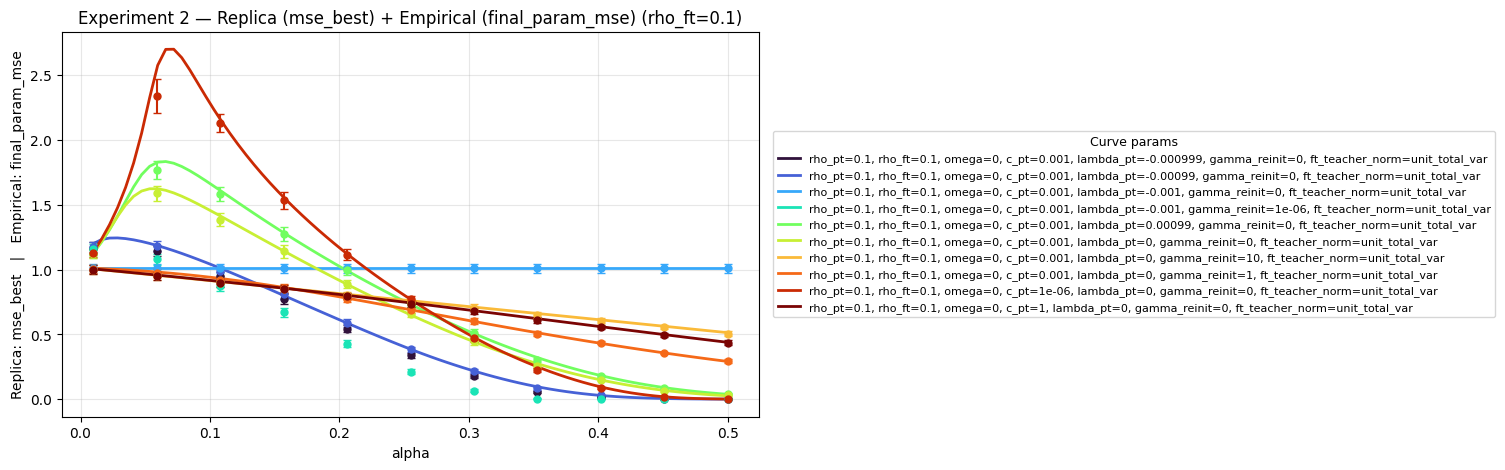

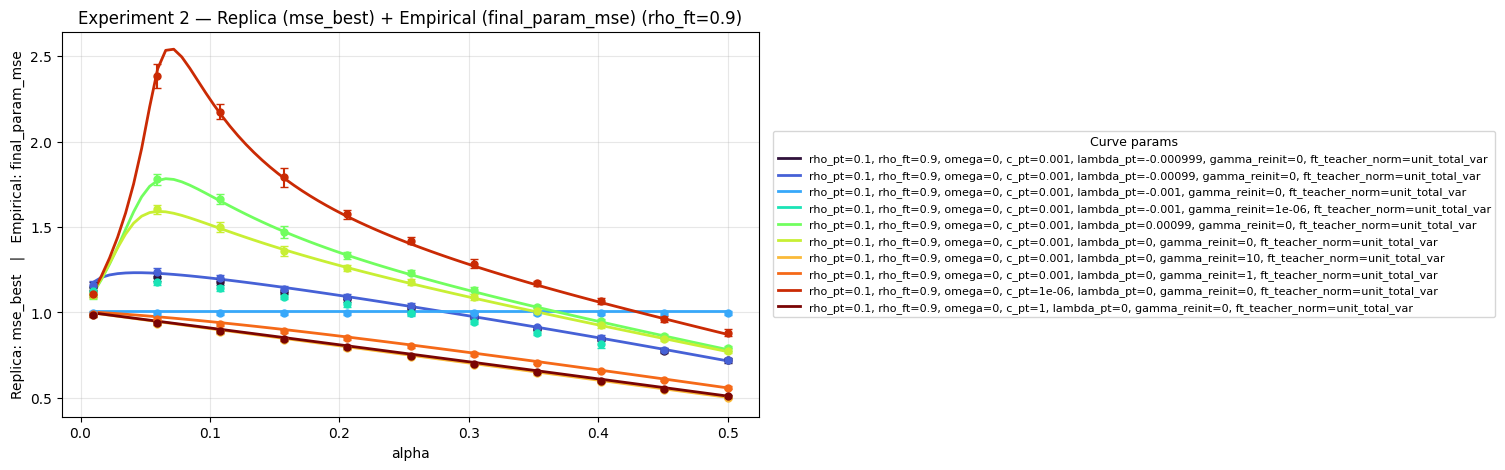

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOL = 1e-12
C_BASE = 1e-3

def _is_close(a, b, tol=TOL):
    return np.isfinite(a) and np.isfinite(b) and abs(a - b) <= tol

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    """
    Stable key across replica+empirical. Rounds numeric cols to avoid tiny float noise.
    """
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0]
    for p in parts[1:]:
        out = out.astype(str) + "|" + p.astype(str)
    return out

def format_params_label(row, cols, float_round=6):
    """
    Pretty legend label containing ALL params for this curve.
    """
    bits = []
    for c in cols:
        if c not in row.index:
            continue
        v = row[c]
        if pd.isna(v):
            continue
        if isinstance(v, (float, np.floating, int, np.integer)):
            vv = float(v)
            bits.append(f"{c}={vv:.{float_round}g}")
        else:
            bits.append(f"{c}={v}")
    return ", ".join(bits)

# -----------------------
# Metrics
# -----------------------
rep_metric = "mse_best"
emp_metric = "final_param_mse"

rep = exp2_replica_df.copy()
emp = exp2_emp_df.copy()

# omega=0 if present
if "omega" in rep.columns:
    rep = rep[np.abs(pd.to_numeric(rep["omega"], errors="coerce")) <= TOL].copy()
if "omega" in emp.columns:
    emp = emp[np.abs(pd.to_numeric(emp["omega"], errors="coerce")) <= TOL].copy()

# sanity
for col in ["alpha", "rho_ft"]:
    if col not in rep.columns or col not in emp.columns:
        raise KeyError(f"Need '{col}' in both dataframes.")
if rep_metric not in rep.columns:
    raise KeyError(f"Replica metric '{rep_metric}' missing.")
if emp_metric not in emp.columns:
    raise KeyError(f"Empirical metric '{emp_metric}' missing.")
if "seed" not in emp.columns:
    raise KeyError("Empirical df must have 'seed'.")

rep = ensure_numeric(rep, ["alpha","rho_ft","rho_pt","c_pt","lambda_pt","gamma_reinit"])
emp = ensure_numeric(emp, ["alpha","rho_ft","rho_pt","c_pt","lambda_pt","gamma_reinit"])

# -----------------------
# Define "param combo identity" columns (use intersection of both dfs)
# -----------------------
candidate_combo_cols = ["rho_pt", "rho_ft", "omega", "c_pt", "lambda_pt", "gamma_reinit", "ft_teacher_norm"]
combo_cols = [c for c in candidate_combo_cols if (c in rep.columns and c in emp.columns)]
if len(combo_cols) == 0:
    raise ValueError("No shared combo columns found between replica and empirical to define curve identity.")

rep["combo_key"] = make_combo_key(rep, combo_cols)
emp["combo_key"] = make_combo_key(emp, combo_cols)

# -----------------------
# Empirical stats (mean ± 95% CI) per combo_key and alpha
# -----------------------
emp_stats = (
    emp.dropna(subset=["combo_key", "alpha", emp_metric])
       .groupby(["rho_ft", "combo_key", "alpha"], as_index=False)
       .agg(
           mean=(emp_metric, "mean"),
           std=(emp_metric, "std"),
           n=("seed", "nunique"),
       )
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# -----------------------
# Precompute per-combo legend labels from empirical (preferred),
# falling back to replica if needed.
# -----------------------
# Use the first row for each combo_key to build a full param label.
emp_combo_rows = (
    emp.dropna(subset=["combo_key"])
       .sort_values(combo_cols)
       .groupby("combo_key", as_index=False)
       .first()
       .set_index("combo_key")
)
rep_combo_rows = (
    rep.dropna(subset=["combo_key"])
       .sort_values(combo_cols)
       .groupby("combo_key", as_index=False)
       .first()
       .set_index("combo_key")
)

def get_combo_label(ck):
    if ck in emp_combo_rows.index:
        row = emp_combo_rows.loc[ck]
    else:
        row = rep_combo_rows.loc[ck]
    return format_params_label(row, combo_cols, float_round=6)

# -----------------------
# Plot per rho_ft: only replica curves that exist in empirical
# Each curve gets its own color; legend lists ALL params, outside the axes.
# -----------------------
for rho in [0.1, 0.9]:
    rep_r = rep[np.isclose(rep["rho_ft"], rho)].copy()
    emp_r = emp_stats[np.isclose(emp_stats["rho_ft"], rho)].copy()

    # which exact combos exist empirically at this rho?
    combo_keys = sorted(emp_r["combo_key"].unique())
    if len(combo_keys) == 0:
        print(f"[warn] No empirical combos found for rho_ft={rho}; skipping plot.")
        continue

    # filter replica to only those combos
    rep_r = rep_r[rep_r["combo_key"].isin(combo_keys)].copy()

    # color per combo_key (use a colormap with many distinct colors)
    cmap = plt.get_cmap("turbo")  # good separation across many curves
    color_map = {ck: cmap(i / max(1, len(combo_keys) - 1)) for i, ck in enumerate(combo_keys)}

    fig, ax = plt.subplots(figsize=(9, 5))

    # Replica curves: ONE curve per combo_key
    for ck in combo_keys:
        d = rep_r[rep_r["combo_key"] == ck].dropna(subset=["alpha", rep_metric]).sort_values("alpha")
        if d.empty:
            continue
        ax.plot(
            d["alpha"].to_numpy(),
            d[rep_metric].to_numpy(),
            lw=2,
            color=color_map[ck],
            zorder=2,
        )

    # Empirical points: mean ± 95% CI per combo_key, alpha
    for ck in combo_keys:
        d = emp_r[emp_r["combo_key"] == ck].sort_values("alpha")
        if d.empty:
            continue
        ax.errorbar(
            d["alpha"].to_numpy(),
            d["mean"].to_numpy(),
            yerr=d["ci95"].to_numpy(),
            fmt="o",
            ms=5,
            capsize=3,
            color=color_map[ck],
            zorder=3,
        )

    ax.set_title(f"Experiment 2 — Replica ({rep_metric}) + Empirical ({emp_metric}) (rho_ft={rho})")
    ax.set_xlabel("alpha")
    ax.set_ylabel(f"Replica: {rep_metric}   |   Empirical: {emp_metric}")
    ax.grid(True, alpha=0.3)

    # Legend: one entry per curve, with full params
    handles = []
    labels = []
    for ck in combo_keys:
        h, = ax.plot([], [], lw=2, color=color_map[ck])
        handles.append(h)
        labels.append(get_combo_label(ck))

    # Put legend outside to the right
    ax.legend(
        handles, labels,
        title="Curve params",
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    # Make room for the outside legend
    # plt.tight_layout(rect=[0, 0, 0.72, 1])
    plt.show()

In [54]:
cols_to_check = ["rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "seed", "ft_teacher_norm"]
rep_r[rep_r["setup_label"]=="c_pt=0.001"][cols_to_check].drop_duplicates().sort_values(cols_to_check)

KeyError: 'setup_label'

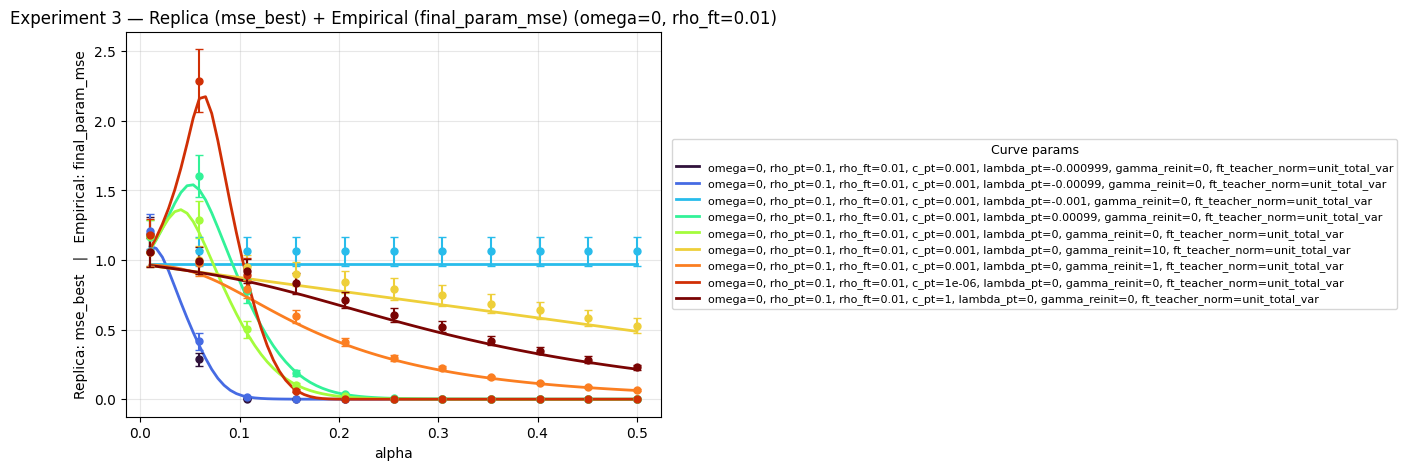

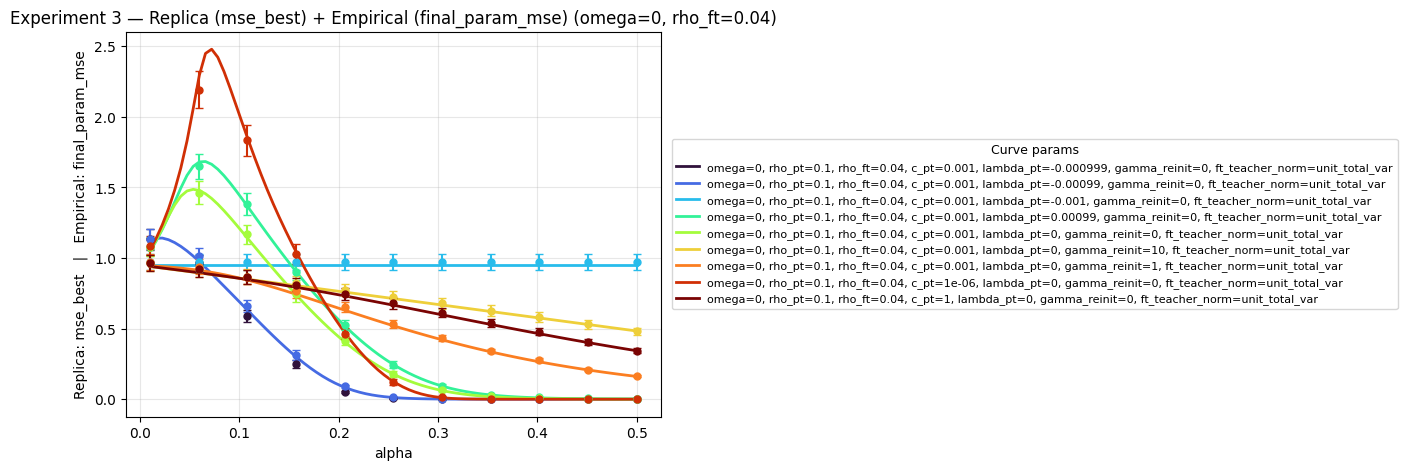

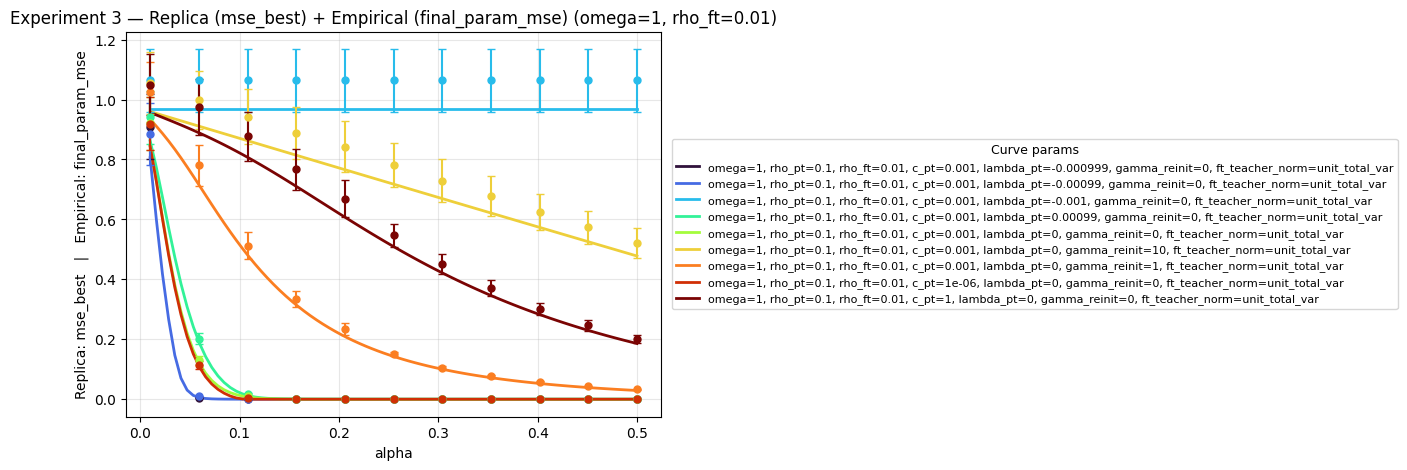

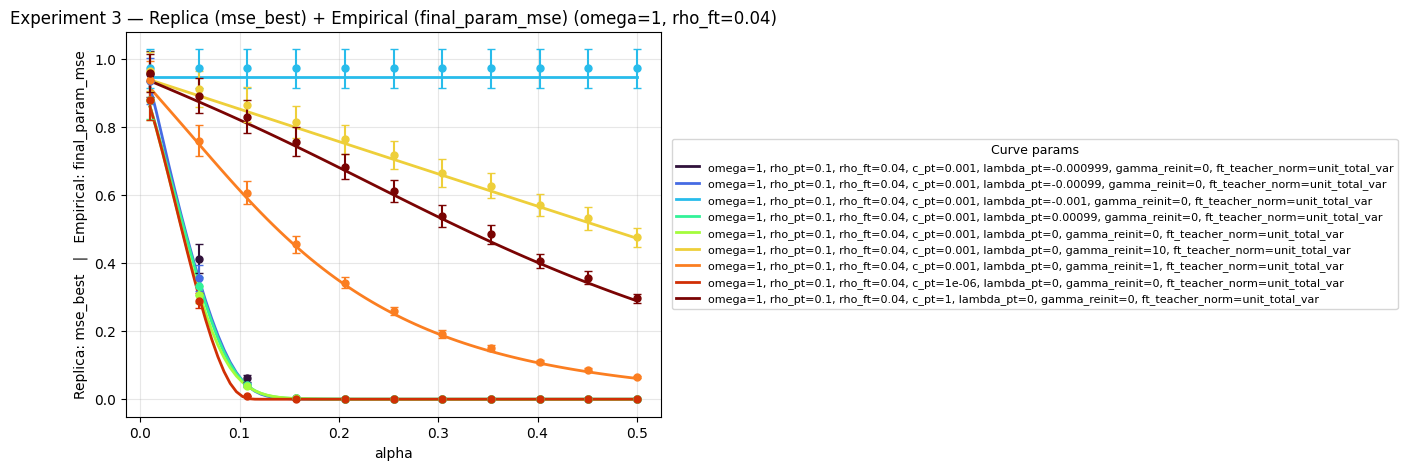

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0]
    for p in parts[1:]:
        out = out.astype(str) + "|" + p.astype(str)
    return out

def format_params_label(row, cols, float_round=6):
    bits = []
    for c in cols:
        if c not in row.index:
            continue
        v = row[c]
        if pd.isna(v):
            continue
        if isinstance(v, (float, np.floating, int, np.integer)):
            bits.append(f"{c}={float(v):.{float_round}g}")
        else:
            bits.append(f"{c}={v}")
    return ", ".join(bits)

# -----------------------
# INPUT dfs (assumed already in memory)
# -----------------------
rep = exp3_replica_df.copy()
emp = exp3_emp_df.copy()

# -----------------------
# Metrics
# -----------------------
rep_metric = "mse_best"
emp_metric = "final_param_mse"

# -----------------------
# Sanity + numeric coercion
# -----------------------
need_rep = ["alpha", "omega", "rho_ft", rep_metric]
need_emp = ["alpha", "omega", "rho_ft", "seed", emp_metric]
for c in need_rep:
    if c not in rep.columns:
        raise KeyError(f"Replica df missing '{c}'")
for c in need_emp:
    if c not in emp.columns:
        raise KeyError(f"Empirical df missing '{c}'")

rep = ensure_numeric(rep, ["alpha", "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])
emp = ensure_numeric(emp, ["alpha", "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])

# -----------------------
# Define param combo identity (shared cols)
# -----------------------
candidate_combo_cols = ["omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "ft_teacher_norm"]
combo_cols = [c for c in candidate_combo_cols if (c in rep.columns and c in emp.columns)]
if len(combo_cols) == 0:
    raise ValueError("No shared combo columns found between replica and empirical to define curve identity.")

rep["combo_key"] = make_combo_key(rep, combo_cols)
emp["combo_key"] = make_combo_key(emp, combo_cols)

# -----------------------
# Empirical stats: mean ± 95% CI per combo_key and alpha
# -----------------------
emp_stats = (
    emp.dropna(subset=["combo_key", "alpha", emp_metric])
       .groupby(["omega", "rho_ft", "combo_key", "alpha"], as_index=False)
       .agg(
           mean=(emp_metric, "mean"),
           std=(emp_metric, "std"),
           n=("seed", "nunique"),
       )
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# -----------------------
# Legend labels from empirical (preferred), fallback to replica
# -----------------------
emp_combo_rows = (
    emp.dropna(subset=["combo_key"])
       .sort_values(combo_cols)
       .groupby("combo_key", as_index=False)
       .first()
       .set_index("combo_key")
)
rep_combo_rows = (
    rep.dropna(subset=["combo_key"])
       .sort_values(combo_cols)
       .groupby("combo_key", as_index=False)
       .first()
       .set_index("combo_key")
)

def get_combo_label(ck):
    row = emp_combo_rows.loc[ck] if ck in emp_combo_rows.index else rep_combo_rows.loc[ck]
    return format_params_label(row, combo_cols, float_round=6)

# -----------------------
# Plot FOUR figures: (omega, rho_ft) in {(0,0.01),(0,0.04),(1,0.01),(1,0.04)}
# Only plot replica curves that exist in empirical for that (omega, rho_ft).
# No tight_layout (per request).
# -----------------------
pairs = [(0.0, 0.01), (0.0, 0.04), (1.0, 0.01), (1.0, 0.04)]

for om, rf in pairs:
    rep_f = rep[np.isclose(rep["omega"], om) & np.isclose(rep["rho_ft"], rf)].copy()
    emp_f = emp_stats[np.isclose(emp_stats["omega"], om) & np.isclose(emp_stats["rho_ft"], rf)].copy()

    combo_keys = sorted(emp_f["combo_key"].unique())
    if len(combo_keys) == 0:
        print(f"[warn] No empirical combos for omega={om}, rho_ft={rf}; skipping.")
        continue

    # only replica curves that have empirical data
    rep_f = rep_f[rep_f["combo_key"].isin(combo_keys)].copy()

    # Color per curve
    cmap = plt.get_cmap("turbo")
    color_map = {ck: cmap(i / max(1, len(combo_keys) - 1)) for i, ck in enumerate(combo_keys)}

    fig, ax = plt.subplots(figsize=(9, 5))

    # Replica curves
    for ck in combo_keys:
        d = rep_f[rep_f["combo_key"] == ck].dropna(subset=["alpha", rep_metric]).sort_values("alpha")
        if d.empty:
            continue
        ax.plot(d["alpha"].to_numpy(), d[rep_metric].to_numpy(), lw=2, color=color_map[ck], zorder=2)

    # Empirical points (95% CI)
    for ck in combo_keys:
        d = emp_f[emp_f["combo_key"] == ck].sort_values("alpha")
        if d.empty:
            continue
        ax.errorbar(
            d["alpha"].to_numpy(),
            d["mean"].to_numpy(),
            yerr=d["ci95"].to_numpy(),
            fmt="o",
            ms=5,
            capsize=3,
            color=color_map[ck],
            zorder=3,
        )

    ax.set_title(f"Experiment 3 — Replica ({rep_metric}) + Empirical ({emp_metric}) (omega={int(om)}, rho_ft={rf})")
    ax.set_xlabel("alpha")
    ax.set_ylabel(f"Replica: {rep_metric}   |   Empirical: {emp_metric}")
    ax.grid(True, alpha=0.3)

    # Legend outside to the right (all params)
    handles, labels = [], []
    for ck in combo_keys:
        h, = ax.plot([], [], lw=2, color=color_map[ck])
        handles.append(h)
        labels.append(get_combo_label(ck))

    ax.legend(
        handles, labels,
        title="Curve params",
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
    )

    # Leave room for legend (but no tight_layout)
    plt.subplots_adjust(right=0.72)
    plt.show()

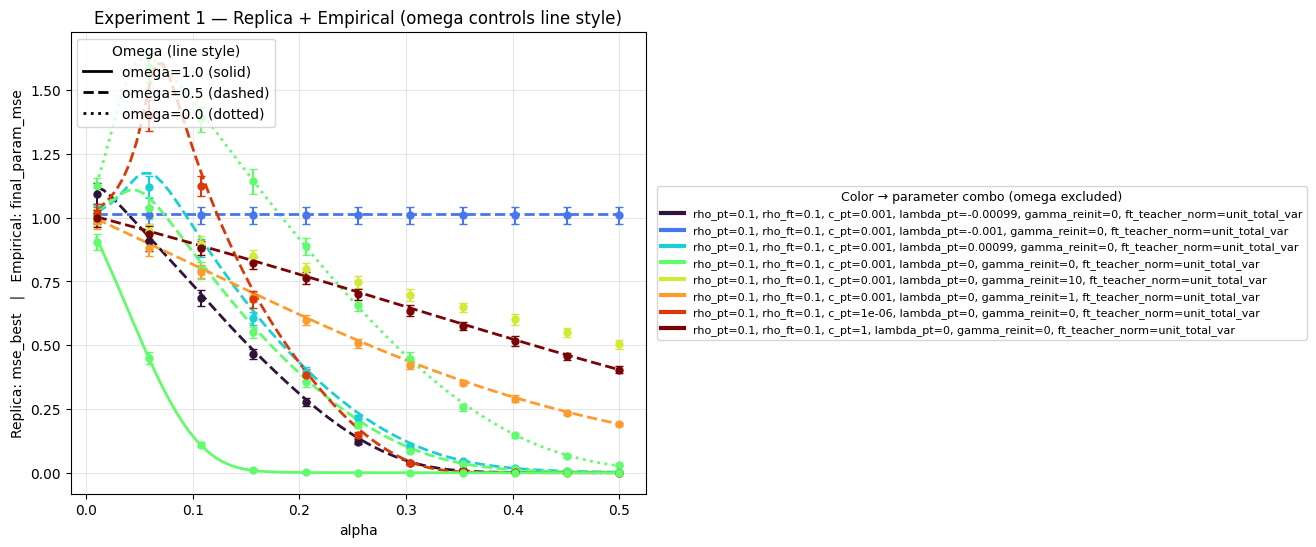

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

def format_params_label(row, cols, float_round=6):
    bits = []
    for c in cols:
        if c not in row.index:
            continue
        v = row[c]
        if pd.isna(v):
            continue
        if isinstance(v, (float, np.floating, int, np.integer)):
            bits.append(f"{c}={float(v):.{float_round}g}")
        else:
            bits.append(f"{c}={v}")
    return ", ".join(bits)

# -----------------------
# INPUT dfs
# -----------------------
rep = exp1_replica_df.copy()
emp = exp1_emp_df.copy()

rep_metric = "mse_best"
emp_metric = "final_param_mse"

# -----------------------
# Sanity
# -----------------------
for c in ["alpha", "omega"]:
    if c not in rep.columns or c not in emp.columns:
        raise KeyError(f"Both dfs must contain '{c}'")

if rep_metric not in rep.columns:
    raise KeyError(f"Replica df missing '{rep_metric}'")
if emp_metric not in emp.columns or "seed" not in emp.columns:
    raise KeyError("Empirical df missing metric or 'seed'")

rep = ensure_numeric(rep, ["alpha","omega","rho_pt","rho_ft","c_pt","lambda_pt","gamma_reinit"])
emp = ensure_numeric(emp, ["alpha","omega","rho_pt","rho_ft","c_pt","lambda_pt","gamma_reinit"])

# -----------------------
# Define BASE param combo (EXCLUDES omega)
# -----------------------
candidate_base_cols = ["rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "ft_teacher_norm"]
base_cols = [c for c in candidate_base_cols if (c in rep.columns and c in emp.columns)]
if not base_cols:
    raise ValueError("No shared base columns found")

rep["base_key"] = make_combo_key(rep, base_cols)
emp["base_key"] = make_combo_key(emp, base_cols)

# Full key (used to filter replica to empirical support)
full_cols = ["omega"] + base_cols
rep["full_key"] = make_combo_key(rep, full_cols)
emp["full_key"] = make_combo_key(emp, full_cols)

# -----------------------
# Empirical stats: mean ± 95% CI
# -----------------------
emp_stats = (
    emp.dropna(subset=["alpha","omega","base_key",emp_metric])
       .groupby(["omega","base_key","alpha"], as_index=False)
       .agg(
           mean=(emp_metric,"mean"),
           std=(emp_metric,"std"),
           n=("seed","nunique"),
       )
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# valid base combos
base_keys = sorted(emp_stats["base_key"].unique())
if not base_keys:
    raise ValueError("No empirical base_key combinations found")

# empirical-supported full keys per omega
emp_fullkeys_by_omega = {
    om: set(emp.loc[np.isclose(emp["omega"], om), "full_key"].unique())
    for om in [0.0, 0.5, 1.0]
}

# labels for color legend
emp_base_rows = emp.groupby("base_key", as_index=False).first().set_index("base_key")
rep_base_rows = rep.groupby("base_key", as_index=False).first().set_index("base_key")

def get_base_label(bk):
    row = emp_base_rows.loc[bk] if bk in emp_base_rows.index else rep_base_rows.loc[bk]
    return format_params_label(row, base_cols)

# -----------------------
# Plot
# -----------------------
cmap = plt.get_cmap("turbo")
color_map = {bk: cmap(i / max(1, len(base_keys)-1)) for i, bk in enumerate(base_keys)}

linestyle_map = {1.0:"-", 0.5:"--", 0.0:":"}
omega_order = [0.0, 0.5, 1.0]

fig, ax = plt.subplots(figsize=(10,6))

# Replica curves
for om in omega_order:
    rep_o = rep[np.isclose(rep["omega"], om)]
    rep_o = rep_o[rep_o["full_key"].isin(emp_fullkeys_by_omega[om])]

    for bk, d in rep_o.groupby("base_key"):
        if bk not in color_map:
            continue
        d = d.sort_values("alpha")
        ax.plot(
            d["alpha"], d[rep_metric],
            color=color_map[bk],
            lw=2,
            linestyle=linestyle_map[om],
            zorder=2
        )

# Empirical points
for om in omega_order:
    s = emp_stats[np.isclose(emp_stats["omega"], om)]
    for bk, d in s.groupby("base_key"):
        if bk not in color_map:
            continue
        d = d.sort_values("alpha")
        ax.errorbar(
            d["alpha"], d["mean"],
            yerr=d["ci95"],
            fmt="o",
            ms=5,
            capsize=3,
            color=color_map[bk],
            zorder=3
        )

ax.set_title("Experiment 1 — Replica + Empirical (omega controls line style)")
ax.set_xlabel("alpha")
ax.set_ylabel(f"Replica: {rep_metric}   |   Empirical: {emp_metric}")
ax.grid(True, alpha=0.3)

# -----------------------
# Legend A: omega (line style) — keep inside
# -----------------------
style_handles = [
    Line2D([0],[0],color="black",lw=2,linestyle=linestyle_map[1.0], label="omega=1.0 (solid)"),
    Line2D([0],[0],color="black",lw=2,linestyle=linestyle_map[0.5], label="omega=0.5 (dashed)"),
    Line2D([0],[0],color="black",lw=2,linestyle=linestyle_map[0.0], label="omega=0.0 (dotted)"),
]
leg_style = ax.legend(
    handles=style_handles,
    title="Omega (line style)",
    loc="upper left",
    frameon=True
)

# -----------------------
# Legend B: color -> param combo (omega excluded) — outside
# -----------------------
param_handles = [Line2D([0],[0],color=color_map[bk],lw=3) for bk in base_keys]
param_labels  = [get_base_label(bk) for bk in base_keys]
leg_color = ax.legend(
    param_handles, param_labels,
    title="Color → parameter combo (omega excluded)",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
)

# Make sure both legends show
ax.add_artist(leg_style)

# Room for outside legend (no tight_layout)
plt.subplots_adjust(right=0.70)
plt.show()

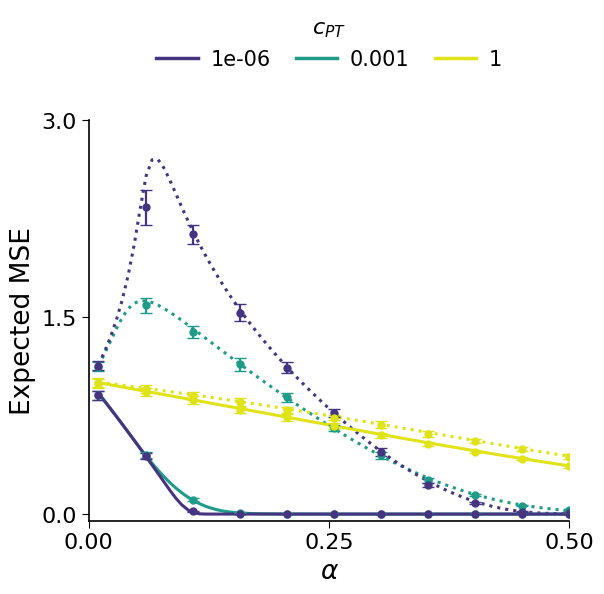

In [13]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# -----------------------
# Global style
# -----------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.fontsize": 15,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.linewidth": 1.2,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "errorbar.capsize": 4,

    "image.cmap": "viridis",
})

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(
                s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}")
            )
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

# -----------------------
# Settings
# -----------------------
EXPERIMENT = "exp1"
RHO_PT = 0.1
RHO_FT = 0.1

rep_metric = "mse_best"
emp_metric = "final_param_mse"

omega_order = [0.0, 1.0]
linestyle_map = {
    0.0: ":",   # dotted
    1.0: "-",   # solid
}

# -----------------------
# Load data
# -----------------------
rep = rep_all_df.copy()
emp = emp_all_df.copy()

num_cols = [
    "alpha","omega","rho_pt","rho_ft","c_pt",
    "lambda_pt","gamma_reinit", rep_metric, emp_metric
]
rep = ensure_numeric(rep, num_cols)
emp = ensure_numeric(emp, num_cols)

rep = rep[rep["experiment"] == EXPERIMENT].copy()
emp = emp[emp["experiment"] == EXPERIMENT].copy()

for df in (rep, emp):
    df.dropna(subset=["alpha","omega"], inplace=True)

rep = rep[np.isclose(rep["rho_pt"], RHO_PT)]
emp = emp[np.isclose(emp["rho_pt"], RHO_PT)]
rep = rep[np.isclose(rep["rho_ft"], RHO_FT)]
emp = emp[np.isclose(emp["rho_ft"], RHO_FT)]
rep = rep[np.isclose(rep["lambda_pt"], 0.0)]
emp = emp[np.isclose(emp["lambda_pt"], 0.0)]
rep = rep[np.isclose(rep["gamma_reinit"], 0.0)]
emp = emp[np.isclose(emp["gamma_reinit"], 0.0)]

rep = rep[rep["omega"].isin([0.0, 1.0])]
emp = emp[emp["omega"].isin([0.0, 1.0])]

# -----------------------
# Color identity
# -----------------------
base_cols = [
    c for c in ["rho_pt","rho_ft","c_pt","lambda_pt","gamma_reinit","ft_teacher_norm"]
    if c in rep.columns and c in emp.columns
]

rep["base_key"] = make_combo_key(rep, base_cols)
emp["base_key"] = make_combo_key(emp, base_cols)

rep["full_key"] = make_combo_key(rep, ["omega"] + base_cols)
emp["full_key"] = make_combo_key(emp, ["omega"] + base_cols)

emp_stats = (
    emp.groupby(["omega","base_key","alpha"], as_index=False)
       .agg(mean=(emp_metric,"mean"),
            std=(emp_metric,"std"),
            n=("seed","nunique"))
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

base_keys = sorted(emp_stats["base_key"].unique())
tmp = emp.groupby("base_key", as_index=False).first()
base_to_cpt = dict(zip(tmp["base_key"], tmp["c_pt"]))
ordered_base_keys = sorted(base_keys, key=lambda k: base_to_cpt[k])

cmap = plt.get_cmap("viridis")
lo, hi = 0.15, 0.95
color_map = {
    bk: cmap(lo + (hi - lo) * i / max(1, len(ordered_base_keys) - 1))
    for i, bk in enumerate(ordered_base_keys)
}

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 5.2))

for om in omega_order:
    rep_o = rep[rep["omega"] == om]
    for bk, d in rep_o.groupby("base_key"):
        if bk not in color_map:
            continue
        d = d.sort_values("alpha")
        ax.plot(
            d["alpha"],
            d[rep_metric],
            color=color_map[bk],
            linestyle=linestyle_map[om],
            linewidth=2.2,
            zorder=2,
        )

for om in omega_order:
    s = emp_stats[emp_stats["omega"] == om]
    for bk, d in s.groupby("base_key"):
        if bk not in color_map:
            continue
        d = d.sort_values("alpha")
        ax.errorbar(
            d["alpha"],
            d["mean"],
            yerr=d["ci95"],
            fmt="o",
            ms=5,
            capsize=4,
            elinewidth=1.6,
            color=color_map[bk],
            zorder=3,
        )

# Axes formatting
ax.set_xlim(0.0, 0.5)
ax.set_xticks([0.0, 0.25, 0.5])
ax.set_ylim(-0.05, 3.0)
ax.set_yticks([0.0, 1.5, 3.0])

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Expected MSE")

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# Legends (outside)
handles_c = [Line2D([0],[0], color=color_map[bk], lw=2.5) for bk in ordered_base_keys]
labels_c = [f"{base_to_cpt[bk]:.3g}" for bk in ordered_base_keys]
leg_c = ax.legend(
    handles_c,
    labels_c,
    title=r"$c_{PT}$",
    frameon=False,

    loc="lower center",
    bbox_to_anchor=(0.5, 1.08),  # push legend above axes
    ncol=len(labels_c),          # single row
    columnspacing=1.2,
    handletextpad=0.6,
)
# leg_c = ax.legend(
#     handles_c, labels_c, title=r"$c_{PT}$",
#     frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0)
# )

# handles_o = [
#     Line2D([0],[0], color="black", lw=2, linestyle=":", label="0.0"),
#     Line2D([0],[0], color="black", lw=2, linestyle="-", label="1.0"),
# ]
# leg_o = ax.legend(
#     handles_o, ["0.0", "1.0"], title="$\omega$",
#     frameon=False, loc="upper left", bbox_to_anchor=(1.02, 0.55)
# )
# ax.add_artist(leg_c)

# fig.tight_layout(rect=[0, 0, 0.80, 1])
# fig.tight_layout()
plt.show()

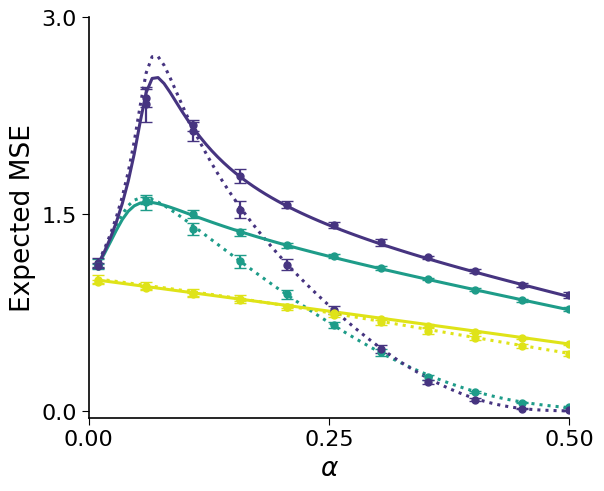

In [16]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# -----------------------
# Global style (MATCHES your final version exactly)
# -----------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.fontsize": 15,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.linewidth": 1.2,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "errorbar.capsize": 4,

    "image.cmap": "viridis",
})

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    """
    Stable key across replica+empirical. Rounds numeric cols to avoid tiny float noise.
    """
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

# -----------------------
# SETTINGS for this panel
# -----------------------
EXPERIMENT = "exp2"      # <-- change if needed
OMEGA_FIXED = 0.0        # "no overlap" = omega = 0
RHO_PT_FIXED = 0.1
RHO_FT_VALUES = [0.1, 0.9]

rep_metric = "mse_best"
emp_metric = "final_param_mse"

# Line style by rho_ft (match aesthetic: one solid, one dotted-ish)
ls_map = {0.1: ":", 0.9: "-"}   # rho_ft=0.1 dotted, rho_ft=0.9 solid (swap if you prefer)

# -----------------------
# Load merged dfs
# -----------------------
rep = rep_all_df.copy()
emp = emp_all_df.copy()

rep = ensure_numeric(rep, ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])
emp = ensure_numeric(emp, ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])

# filter experiment if merged
if "experiment" in rep.columns:
    rep = rep[rep["experiment"] == EXPERIMENT].copy()
if "experiment" in emp.columns:
    emp = emp[emp["experiment"] == EXPERIMENT].copy()

# required columns
need_rep = ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"]
need_emp = ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "seed"]
miss_rep = [c for c in need_rep if c not in rep.columns]
miss_emp = [c for c in need_emp if c not in emp.columns]
if miss_rep:
    raise KeyError(f"Replica df missing required columns: {miss_rep}")
if miss_emp:
    raise KeyError(f"Empirical df missing required columns: {miss_emp}")

# -----------------------
# FIXED PARAMS
# -----------------------
def apply_filters(df):
    df = df[np.isclose(df["omega"], OMEGA_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["rho_pt"], RHO_PT_FIXED, atol=1e-9)].copy()
    df = df[df["rho_ft"].isin(RHO_FT_VALUES)].copy()
    df = df[np.isclose(df["lambda_pt"], 0.0, atol=1e-9)].copy()
    df = df[np.isclose(df["gamma_reinit"], 0.0, atol=1e-9)].copy()
    df = df.dropna(subset=["alpha", "rho_ft"]).copy()
    return df

rep = apply_filters(rep)
emp = apply_filters(emp)

# -----------------------
# Define "base combo" key for COLOR that does NOT include rho_ft
# -----------------------
candidate_base_cols = ["omega", "rho_pt", "c_pt", "lambda_pt", "gamma_reinit", "ft_teacher_norm"]
base_cols = [c for c in candidate_base_cols if (c in rep.columns and c in emp.columns)]
if len(base_cols) == 0:
    raise ValueError("No shared base columns found to define color combos.")

rep["base_key"] = make_combo_key(rep, base_cols)
emp["base_key"] = make_combo_key(emp, base_cols)

# Full key includes rho_ft
full_cols = base_cols + ["rho_ft"]
rep["full_key"] = make_combo_key(rep, full_cols)
emp["full_key"] = make_combo_key(emp, full_cols)

# Only plot replica curves that have empirical data
emp_fullkeys = set(emp["full_key"].dropna().unique())
rep = rep[rep["full_key"].isin(emp_fullkeys)].copy()

# -----------------------
# Empirical stats: mean ± 95% CI (1.96*SE) per (rho_ft, base_key, alpha)
# -----------------------
emp_stats = (
    emp.dropna(subset=["alpha", emp_metric, "full_key", "base_key"])
       .groupby(["rho_ft", "base_key", "full_key", "alpha"], as_index=False)
       .agg(
           mean=(emp_metric, "mean"),
           std=(emp_metric, "std"),
           n=("seed", "nunique"),
       )
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# -----------------------
# Colors: viridis (MATCHES your final version)
# -----------------------
tmp = emp.dropna(subset=["base_key", "c_pt"]).groupby("base_key", as_index=False).first()
base_to_cpt = dict(zip(tmp["base_key"], tmp["c_pt"]))

base_keys = sorted(emp_stats["base_key"].unique())
if len(base_keys) == 0:
    raise ValueError("No empirical base_keys found after filtering.")

ordered_base_keys = sorted(base_keys, key=lambda bk: float(base_to_cpt.get(bk, np.inf)))

cmap = plt.get_cmap("viridis")
lo, hi = 0.15, 0.95
color_map = {
    bk: cmap(lo + (hi - lo) * i / max(1, len(ordered_base_keys) - 1))
    for i, bk in enumerate(ordered_base_keys)
}

# -----------------------
# Plot (MATCHES your final version geometry + axes formatting)
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 5.2))

# Replica curves
for rf in RHO_FT_VALUES:
    d_rf = rep[np.isclose(rep["rho_ft"], rf, atol=1e-12)].copy()
    for bk, d in d_rf.groupby("base_key"):
        if bk not in color_map:
            continue
        d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
        if d.empty:
            continue
        ax.plot(
            d["alpha"].to_numpy(),
            d[rep_metric].to_numpy(),
            color=color_map[bk],
            linestyle=ls_map[rf],
            linewidth=2.2,
            zorder=2,
        )

# Empirical points + 95% CI
for rf in RHO_FT_VALUES:
    s = emp_stats[np.isclose(emp_stats["rho_ft"], rf, atol=1e-12)].copy()
    for bk, d in s.groupby("base_key"):
        if bk not in color_map:
            continue
        d = d.sort_values("alpha")
        if d.empty:
            continue
        ax.errorbar(
            d["alpha"].to_numpy(),
            d["mean"].to_numpy(),
            yerr=d["ci95"].to_numpy(),
            fmt="o",
            ms=5,
            capsize=4,
            elinewidth=1.6,
            color=color_map[bk],
            zorder=3,
        )

# Axes formatting (same as your final version)
ax.set_xlim(0.0, 0.5)
ax.set_xticks([0.0, 0.25, 0.5])
ax.set_ylim(-0.05, 3.0)
ax.set_yticks([0.0, 1.5, 3.0])

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Expected MSE")

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# Legends outside (same layout style)
handles_c = [Line2D([0],[0], color=color_map[bk], lw=2.5) for bk in ordered_base_keys]
labels_c  = [f"{float(base_to_cpt.get(bk, np.nan)):.3g}" for bk in ordered_base_keys]
# leg_c = ax.legend(
#     handles_c, labels_c,
#     title=r"$c_{PT}$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(1.0, 1.0),
# )

# rf_handles = [
#     Line2D([0],[0], color="black", lw=2, linestyle=ls_map[0.1], label="0.1"),
#     Line2D([0],[0], color="black", lw=2, linestyle=ls_map[0.9], label="0.9"),
# ]
# leg_rf = ax.legend(
#     rf_handles, ["0.1", "0.9"],
#     title=r"$\rho_{FT}$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(1.02, 0.55),
# )

# ax.add_artist(leg_c)

# fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

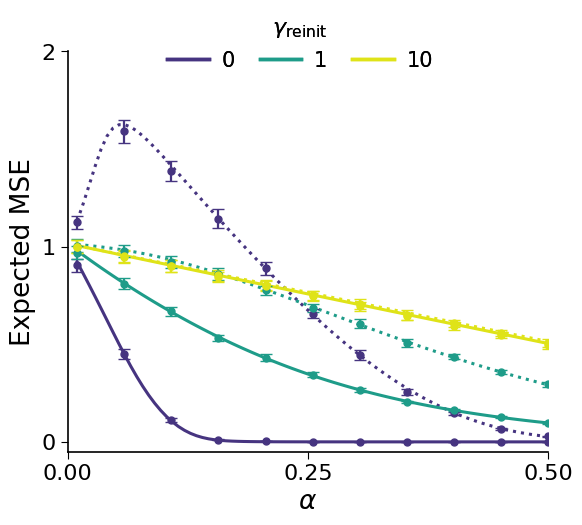

In [21]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# -----------------------
# Global style (EXACT match to your final version)
# -----------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.fontsize": 15,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.linewidth": 1.2,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "errorbar.capsize": 4,

    "image.cmap": "viridis",
})

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(
                s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}")
            )
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

# -----------------------
# SETTINGS (panel c)
# -----------------------
EXPERIMENT = "exp1"
RHO_PT_FIXED = 0.1
RHO_FT_FIXED = 0.1

C_PT_FIXED = 1e-3
LAMBDA_PT_FIXED = 0.0

GAMMA_VALUES = None      # auto-detect if None
OMEGA_VALUES = [0.0, 1.0]

# omega style: 0 dotted, 1 solid (consistent with earlier figures)
ls_map = {0.0: ":", 1.0: "-"}

rep_metric = "mse_best"
emp_metric = "final_param_mse"

# -----------------------
# Load data
# -----------------------
rep = rep_all_df.copy()
emp = emp_all_df.copy()

rep = ensure_numeric(rep, ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])
emp = ensure_numeric(emp, ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])

if "experiment" in rep.columns:
    rep = rep[rep["experiment"] == EXPERIMENT].copy()
if "experiment" in emp.columns:
    emp = emp[emp["experiment"] == EXPERIMENT].copy()

# -----------------------
# Apply fixed parameters
# -----------------------
def apply_filters(df):
    df = df[np.isclose(df["rho_pt"], RHO_PT_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["rho_ft"], RHO_FT_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["c_pt"], C_PT_FIXED, atol=1e-12)].copy()
    df = df[np.isclose(df["lambda_pt"], LAMBDA_PT_FIXED, atol=1e-12)].copy()
    df = df[df["omega"].isin(OMEGA_VALUES)].copy()
    df = df.dropna(subset=["alpha", "omega", "gamma_reinit"]).copy()
    return df

rep = apply_filters(rep)
emp = apply_filters(emp)

# -----------------------
# Gamma values
# -----------------------
if GAMMA_VALUES is None:
    gamma_vals = sorted(
        set(rep["gamma_reinit"].dropna().unique()) |
        set(emp["gamma_reinit"].dropna().unique())
    )
else:
    gamma_vals = GAMMA_VALUES

if not gamma_vals:
    raise ValueError("No gamma_reinit values found after filtering.")

# -----------------------
# Color map (viridis, ordered by gamma)
# -----------------------
cmap = plt.get_cmap("viridis")
lo, hi = 0.15, 0.95
color_map = {
    g: cmap(lo + (hi - lo) * i / max(1, len(gamma_vals) - 1))
    for i, g in enumerate(gamma_vals)
}

# -----------------------
# Match replica to empirical support
# -----------------------
rep["full_key"] = make_combo_key(rep, ["omega", "gamma_reinit"])
emp["full_key"] = make_combo_key(emp, ["omega", "gamma_reinit"])
rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

# -----------------------
# Empirical stats
# -----------------------
emp_stats = (
    emp.groupby(["omega", "gamma_reinit", "alpha"], as_index=False)
       .agg(
           mean=(emp_metric, "mean"),
           std=(emp_metric, "std"),
           n=("seed", "nunique"),
       )
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 5.2))

# Replica curves
for g in gamma_vals:
    for om in OMEGA_VALUES:
        d = rep[(rep["gamma_reinit"] == g) & (rep["omega"] == om)]
        if d.empty:
            continue
        d = d.sort_values("alpha")
        ax.plot(
            d["alpha"],
            d[rep_metric],
            color=color_map[g],
            linestyle=ls_map[om],
            linewidth=2.2,
            zorder=2,
        )

# Empirical points + CI
for g in gamma_vals:
    for om in OMEGA_VALUES:
        d = emp_stats[(emp_stats["gamma_reinit"] == g) & (emp_stats["omega"] == om)]
        if d.empty:
            continue
        d = d.sort_values("alpha")
        ax.errorbar(
            d["alpha"],
            d["mean"],
            yerr=d["ci95"],
            fmt="o",
            ms=5,
            capsize=4,
            elinewidth=1.6,
            color=color_map[g],
            zorder=3,
        )

# Axes formatting (MATCH)
ax.set_xlim(0.0, 0.5)
ax.set_xticks([0.0, 0.25, 0.5])
ax.set_ylim(-0.05, 2.0)
ax.set_yticks([0.0, 1.0, 2.0])

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Expected MSE")

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# -----------------------
# Legends (outside, anchor fixed)
# -----------------------
g_handles = [Line2D([0],[0], color=color_map[g], lw=2.5) for g in gamma_vals]
g_labels  = [f"{g:g}" for g in gamma_vals]
# leg_g = ax.legend(
#     g_handles, g_labels,
#     title=r"$\gamma_{\mathrm{reinit}}$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(1.00, 1.0),
# )
leg_g = fig.legend(
    g_handles, g_labels,
    title=r"$\gamma_{\mathrm{reinit}}$",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),   # inside the figure
    ncol=len(g_labels),
    columnspacing=1.2,
    handletextpad=0.6,
)

# o_handles = [
#     Line2D([0],[0], color="black", lw=2, linestyle=":", label="0.0"),
#     Line2D([0],[0], color="black", lw=2, linestyle="-", label="1.0"),
# ]

# leg_o = ax.legend(
#     o_handles, ["0.0", "1.0"],
#     title=r"$\omega$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(1.00, 0.55),
# )
ax.add_artist(leg_g)

# fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

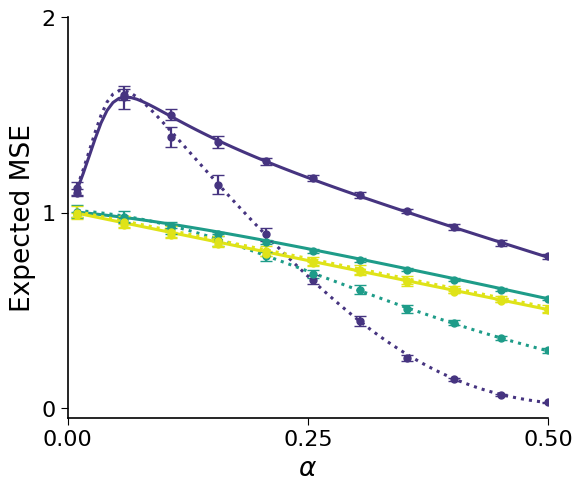

In [23]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# -----------------------
# Global style (EXACT match to your final version)
# -----------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.fontsize": 15,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.linewidth": 1.2,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "errorbar.capsize": 4,

    "image.cmap": "viridis",
})

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

# -----------------------
# SETTINGS (panel f)
# -----------------------
EXPERIMENT = "exp2"
OMEGA_FIXED = 0.0
RHO_PT_FIXED = 0.1
RHO_FT_VALUES = [0.1, 0.9]

C_PT_FIXED = 1e-3
LAMBDA_PT_FIXED = 0.0

GAMMA_VALUES = None  # auto-detect if None

rep_metric = "mse_best"
emp_metric = "final_param_mse"

# Linestyle by rho_ft (to match your aesthetic: 0.1 dotted, 0.9 solid)
ls_map = {0.1: ":", 0.9: "-"}

# -----------------------
# Load data
# -----------------------
rep = rep_all_df.copy()
emp = emp_all_df.copy()

rep = ensure_numeric(rep, ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])
emp = ensure_numeric(emp, ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"])

if "experiment" in rep.columns:
    rep = rep[rep["experiment"] == EXPERIMENT].copy()
if "experiment" in emp.columns:
    emp = emp[emp["experiment"] == EXPERIMENT].copy()

# required columns
need_rep = ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"]
need_emp = ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "seed"]
miss_rep = [c for c in need_rep if c not in rep.columns]
miss_emp = [c for c in need_emp if c not in emp.columns]
if miss_rep:
    raise KeyError(f"Replica df missing required columns: {miss_rep}")
if miss_emp:
    raise KeyError(f"Empirical df missing required columns: {miss_emp}")

# -----------------------
# FIX params in BOTH dfs
# -----------------------
def apply_filters(df):
    df = df[np.isclose(df["omega"], OMEGA_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["rho_pt"], RHO_PT_FIXED, atol=1e-9)].copy()
    df = df[df["rho_ft"].isin(RHO_FT_VALUES)].copy()
    df = df[np.isclose(df["c_pt"], C_PT_FIXED, atol=1e-12)].copy()
    df = df[np.isclose(df["lambda_pt"], LAMBDA_PT_FIXED, atol=1e-12)].copy()
    df = df.dropna(subset=["alpha", "rho_ft", "gamma_reinit"]).copy()
    return df

rep = apply_filters(rep)
emp = apply_filters(emp)

# Determine gamma values present
if GAMMA_VALUES is None:
    gamma_vals = sorted(
        set(rep["gamma_reinit"].dropna().unique()) |
        set(emp["gamma_reinit"].dropna().unique())
    )
else:
    gamma_vals = list(GAMMA_VALUES)

if len(gamma_vals) == 0:
    raise ValueError("No gamma_reinit values found after filtering. Check EXPERIMENT / fixed params.")

# -----------------------
# Color: viridis by gamma_reinit (MATCH style)
# -----------------------
cmap = plt.get_cmap("viridis")
lo, hi = 0.15, 0.95
color_map = {
    g: cmap(lo + (hi - lo) * i / max(1, len(gamma_vals) - 1))
    for i, g in enumerate(gamma_vals)
}

# -----------------------
# Only plot replica curves that have empirical support
# key for existence = (rho_ft, gamma_reinit)
# -----------------------
rep["full_key"] = make_combo_key(rep, ["rho_ft", "gamma_reinit"])
emp["full_key"] = make_combo_key(emp, ["rho_ft", "gamma_reinit"])
rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

# -----------------------
# Empirical stats: mean ± 95% CI (1.96*SE)
# per (rho_ft, gamma, alpha)
# -----------------------
emp_stats = (
    emp.dropna(subset=["alpha", emp_metric, "rho_ft", "gamma_reinit"])
       .groupby(["rho_ft", "gamma_reinit", "alpha"], as_index=False)
       .agg(
           mean=(emp_metric, "mean"),
           std=(emp_metric, "std"),
           n=("seed", "nunique"),
       )
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 5.2))

# Replica curves (color by gamma, linestyle by rho_ft)
for g in gamma_vals:
    for rf in RHO_FT_VALUES:
        d = rep[(rep["gamma_reinit"] == g) & (rep["rho_ft"] == rf)]
        if d.empty:
            continue
        d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
        ax.plot(
            d["alpha"].to_numpy(),
            d[rep_metric].to_numpy(),
            color=color_map[g],
            linestyle=ls_map[rf],
            linewidth=2.2,
            zorder=2,
        )

# Empirical points + 95% CI
for g in gamma_vals:
    for rf in RHO_FT_VALUES:
        d = emp_stats[(emp_stats["gamma_reinit"] == g) & (emp_stats["rho_ft"] == rf)]
        if d.empty:
            continue
        d = d.sort_values("alpha")
        ax.errorbar(
            d["alpha"].to_numpy(),
            d["mean"].to_numpy(),
            yerr=d["ci95"].to_numpy(),
            fmt="o",
            ms=5,
            capsize=4,
            elinewidth=1.6,
            color=color_map[g],
            zorder=3,
        )

# Axes formatting (MATCH)
ax.set_xlim(0.0, 0.5)
ax.set_xticks([0.0, 0.25, 0.5])
ax.set_ylim(-0.05, 2.0)
ax.set_yticks([0.0, 1.0, 2.0])

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Expected MSE")

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# -----------------------
# Legends (outside, with the "1.00, 1.0" anchor fix)
# -----------------------
# g_handles = [Line2D([0],[0], color=color_map[g], lw=2.5) for g in gamma_vals]
# g_labels  = [f"{g:g}" for g in gamma_vals]
# leg_g = ax.legend(
#     g_handles, g_labels,
#     title=r"$\gamma_{\mathrm{reinit}}$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(1.00, 1.0),
# )

# rf_handles = [
#     Line2D([0],[0], color="black", lw=2, linestyle=ls_map[0.1], label="0.1"),
#     Line2D([0],[0], color="black", lw=2, linestyle=ls_map[0.9], label="0.9"),
# ]
# leg_rf = ax.legend(
#     rf_handles, ["0.1", "0.9"],
#     title=r"$\rho_{FT}$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(1.00, 0.55),
# )

# ax.add_artist(leg_g)

# fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

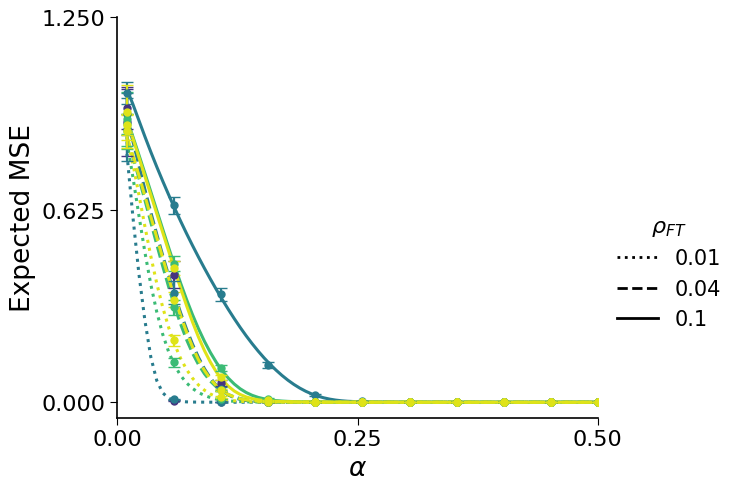

In [27]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# -----------------------
# Global style (EXACT match to your final version)
# -----------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.fontsize": 15,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.linewidth": 1.2,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "errorbar.capsize": 4,

    "image.cmap": "viridis",
})

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

# -----------------------
# SETTINGS: vary lambda_pt; rho_ft styles; omega fixed
# -----------------------
OMEGA_FIXED = 1.0
RHO_PT_FIXED = 0.1
C_PT_FIXED = 1e-3
GAMMA_FIXED = 0.0

RHO_FT_KEEP = [0.01, 0.04, 0.1]   # or None

rep_metric = "mse_best"
emp_metric = "final_param_mse"

# rho_ft -> linestyle
ls_map = {0.01: ":", 0.04: "--", 0.1: "-"}

# -----------------------
# Load dfs
# -----------------------
rep = ensure_numeric(
    rep_all_df.copy(),
    ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"]
)
emp = ensure_numeric(
    emp_all_df.copy(),
    ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "seed"]
)

# -----------------------
# Filter by parameter combo (NOT by experiment)
# -----------------------
def apply_filters(df):
    df = df[np.isclose(df["omega"], OMEGA_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["rho_pt"], RHO_PT_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["c_pt"], C_PT_FIXED, atol=1e-12)].copy()
    df = df[np.isclose(df["gamma_reinit"], GAMMA_FIXED, atol=1e-12)].copy()
    if RHO_FT_KEEP is not None:
        df = df[df["rho_ft"].isin(RHO_FT_KEEP)].copy()
    df = df.dropna(subset=["alpha", "rho_ft", "lambda_pt"]).copy()
    return df

rep = apply_filters(rep)
emp = apply_filters(emp)

# Exclude lambda_pt == -c_pt
rep = rep[~np.isclose(rep["lambda_pt"], -rep["c_pt"], atol=1e-12)].copy()
emp = emp[~np.isclose(emp["lambda_pt"], -emp["c_pt"], atol=1e-12)].copy()

rho_ft_present = sorted(set(rep["rho_ft"].dropna().unique()) | set(emp["rho_ft"].dropna().unique()))
lambda_vals = sorted(set(rep["lambda_pt"].dropna().unique()) | set(emp["lambda_pt"].dropna().unique()))

if len(rho_ft_present) == 0:
    raise ValueError("No rho_ft values found after filtering.")
if len(lambda_vals) == 0:
    raise ValueError("No lambda_pt values found after filtering.")

# -----------------------
# Colors by lambda (viridis, consistent with your final style)
# -----------------------
lambda_vals_sorted = sorted(lambda_vals)
cmap = plt.get_cmap("viridis")
lo, hi = 0.15, 0.95
color_map = {
    lam: cmap(lo + (hi - lo) * i / max(1, len(lambda_vals_sorted) - 1))
    for i, lam in enumerate(lambda_vals_sorted)
}

# -----------------------
# Only plot replica curves that have empirical support at same (rho_ft, lambda_pt)
# -----------------------
rep["full_key"] = make_combo_key(rep, ["rho_ft", "lambda_pt"])
emp["full_key"] = make_combo_key(emp, ["rho_ft", "lambda_pt"])
rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

# Empirical stats
emp_stats = (
    emp.dropna(subset=["alpha", emp_metric, "rho_ft", "lambda_pt"])
       .groupby(["rho_ft", "lambda_pt", "alpha"], as_index=False)
       .agg(mean=(emp_metric, "mean"), std=(emp_metric, "std"), n=("seed", "nunique"))
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 5.2))

# Replica curves
for lam in lambda_vals_sorted:
    for rf in rho_ft_present:
        d = rep[np.isclose(rep["lambda_pt"], lam, atol=1e-12) & np.isclose(rep["rho_ft"], rf, atol=1e-12)].copy()
        if d.empty:
            continue
        d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
        ax.plot(
            d["alpha"].to_numpy(),
            d[rep_metric].to_numpy(),
            color=color_map[lam],
            linestyle=ls_map.get(rf, "-"),
            linewidth=2.2,
            zorder=2,
        )

# Empirical points
for lam in lambda_vals_sorted:
    for rf in rho_ft_present:
        d = emp_stats[np.isclose(emp_stats["lambda_pt"], lam, atol=1e-12) & np.isclose(emp_stats["rho_ft"], rf, atol=1e-12)].copy()
        if d.empty:
            continue
        d = d.sort_values("alpha")
        ax.errorbar(
            d["alpha"].to_numpy(),
            d["mean"].to_numpy(),
            yerr=d["ci95"].to_numpy(),
            fmt="o",
            ms=5,
            capsize=4,
            elinewidth=1.6,
            color=color_map[lam],
            zorder=3,
        )

# Axes formatting (MATCH)
ax.set_xlim(0.0, 0.5)
ax.set_xticks([0.0, 0.25, 0.5])
ax.set_ylim(-0.05, 1.25)
ax.set_yticks([0.0, 0.625, 1.25])

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Expected MSE")

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# -----------------------
# Legends (outside; apply the 1.00,1.0 anchor fix)
# -----------------------
# lam_handles = [Line2D([0], [0], color=color_map[lam], lw=2.5) for lam in lambda_vals_sorted]
# lam_labels = [f"{lam:.8g}" for lam in lambda_vals_sorted]
# leg_lam = ax.legend(
#     lam_handles, lam_labels,
#     title=r"$\lambda_{PT}$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(0.9, 1.0),
# )

rf_handles = [Line2D([0], [0], color="black", lw=2, linestyle=ls_map.get(rf, "-")) for rf in rho_ft_present]
rf_labels = [f"{rf:g}" for rf in rho_ft_present]
leg_rf = ax.legend(
    rf_handles, rf_labels,
    title=r"$\rho_{FT}$",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.00, 0.55),
)

# ax.add_artist(leg_lam)

# fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

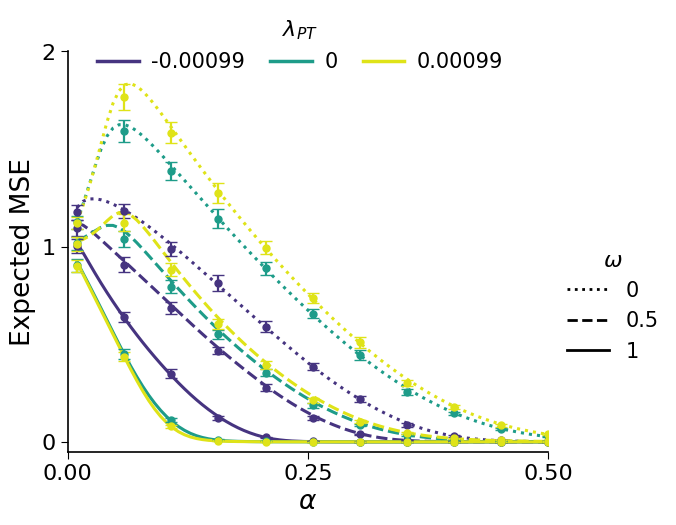

In [25]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# -----------------------
# Global style (EXACT match to your final version)
# -----------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.fontsize": 15,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.linewidth": 1.2,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "errorbar.capsize": 4,

    "image.cmap": "viridis",
})

TOL = 1e-12

def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

# -----------------------
# SETTINGS: fix rho_ft=0.1 and vary omega
# -----------------------
RHO_PT_FIXED = 0.1
RHO_FT_FIXED = 0.1
C_PT_FIXED   = 1e-3
GAMMA_FIXED  = 0.0

OMEGA_VALUES = [0.0, 0.5, 1.0]
# Keep your omega linestyles (these are fine)
ls_map = {0.0: ":", 0.5: "--", 1.0: "-"}

LAMBDA_VALUES = [-1e-3, -0.99e-3, 0.0, 0.99e-3]
EXCLUDE_LAMBDA_EQ_MINUS_C = True

rep_metric = "mse_best"
emp_metric = "final_param_mse"

# -----------------------
# Load dfs (no experiment filter)
# -----------------------
rep = ensure_numeric(
    rep_all_df.copy(),
    ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"]
)
emp = ensure_numeric(
    emp_all_df.copy(),
    ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "seed"]
)

# Sanity: required columns
need_rep = ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"]
need_emp = ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "seed"]
miss_rep = [c for c in need_rep if c not in rep.columns]
miss_emp = [c for c in need_emp if c not in emp.columns]
if miss_rep:
    raise KeyError(f"Replica df missing required columns: {miss_rep}")
if miss_emp:
    raise KeyError(f"Empirical df missing required columns: {miss_emp}")

# -----------------------
# Filter by parameter combo (NOT experiment)
# -----------------------
def apply_filters(df):
    df = df[np.isclose(df["rho_pt"], RHO_PT_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["rho_ft"], RHO_FT_FIXED, atol=1e-9)].copy()
    df = df[np.isclose(df["c_pt"],   C_PT_FIXED,   atol=1e-12)].copy()
    df = df[np.isclose(df["gamma_reinit"], GAMMA_FIXED, atol=1e-12)].copy()
    df = df[df["omega"].isin(OMEGA_VALUES)].copy()
    if LAMBDA_VALUES is not None:
        df = df[df["lambda_pt"].isin(LAMBDA_VALUES)].copy()
    df = df.dropna(subset=["alpha", "omega", "lambda_pt"]).copy()
    return df

rep = apply_filters(rep)
emp = apply_filters(emp)

if EXCLUDE_LAMBDA_EQ_MINUS_C:
    rep = rep[~np.isclose(rep["lambda_pt"], -rep["c_pt"], atol=1e-12)].copy()
    emp = emp[~np.isclose(emp["lambda_pt"], -emp["c_pt"], atol=1e-12)].copy()

# Determine lambda values to plot (post-exclusion)
lambda_vals_sorted = sorted(set(rep["lambda_pt"].dropna().unique()) | set(emp["lambda_pt"].dropna().unique()))
if len(lambda_vals_sorted) == 0:
    raise ValueError("No lambda_pt values found after filtering.")

# Determine omegas actually present
omega_present = sorted(set(rep["omega"].dropna().unique()) | set(emp["omega"].dropna().unique()))
omega_present = [om for om in OMEGA_VALUES if om in omega_present]
if len(omega_present) == 0:
    raise ValueError("No omega values found after filtering. Check OMEGA_VALUES / data.")

# -----------------------
# Colors by lambda (viridis, consistent with your final style)
# -----------------------
cmap = plt.get_cmap("viridis")
lo, hi = 0.15, 0.95
color_map = {
    lam: cmap(lo + (hi - lo) * i / max(1, len(lambda_vals_sorted) - 1))
    for i, lam in enumerate(lambda_vals_sorted)
}

# -----------------------
# Only plot replica curves that have empirical support
# key = (omega, lambda_pt)
# -----------------------
rep["full_key"] = make_combo_key(rep, ["omega", "lambda_pt"])
emp["full_key"] = make_combo_key(emp, ["omega", "lambda_pt"])
rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

# Empirical stats: mean ± 95% CI per (omega, lambda_pt, alpha)
emp_stats = (
    emp.dropna(subset=["alpha", emp_metric, "omega", "lambda_pt"])
      .groupby(["omega", "lambda_pt", "alpha"], as_index=False)
      .agg(mean=(emp_metric, "mean"), std=(emp_metric, "std"), n=("seed", "nunique"))
)
emp_stats["sem"] = emp_stats["std"] / np.sqrt(emp_stats["n"].clip(lower=1))
emp_stats["ci95"] = 1.96 * emp_stats["sem"]

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 5.2))

# Replica curves: color by lambda, linestyle by omega
for lam in lambda_vals_sorted:
    for om in omega_present:
        d = rep[np.isclose(rep["lambda_pt"], lam, atol=1e-12) & np.isclose(rep["omega"], om, atol=1e-12)].copy()
        if d.empty:
            continue
        d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
        ax.plot(
            d["alpha"].to_numpy(),
            d[rep_metric].to_numpy(),
            color=color_map[lam],
            linestyle=ls_map.get(om, "-"),
            linewidth=2.2,
            zorder=2,
        )

# Empirical points + 95% CI: same color by lambda
for lam in lambda_vals_sorted:
    for om in omega_present:
        d = emp_stats[np.isclose(emp_stats["lambda_pt"], lam, atol=1e-12) & np.isclose(emp_stats["omega"], om, atol=1e-12)].copy()
        if d.empty:
            continue
        d = d.sort_values("alpha")
        ax.errorbar(
            d["alpha"].to_numpy(),
            d["mean"].to_numpy(),
            yerr=d["ci95"].to_numpy(),
            fmt="o",
            ms=5,
            capsize=4,
            elinewidth=1.6,
            color=color_map[lam],
            zorder=3,
        )

# Axes formatting (MATCH)
ax.set_xlim(0.0, 0.5)
ax.set_xticks([0.0, 0.25, 0.5])
ax.set_ylim(-0.05, 2.0)
ax.set_yticks([0.0, 1.0, 2.0])

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Expected MSE")

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())

# -----------------------
# Legends (outside; apply the 1.00, 1.0 anchor fix for the first legend)
# -----------------------
# lam_handles = [Line2D([0], [0], color=color_map[lam], lw=2.5) for lam in lambda_vals_sorted]
# lam_labels  = [f"{lam:.8g}" for lam in lambda_vals_sorted]
# leg_lam = ax.legend(
#     lam_handles, lam_labels,
#     title=r"$\lambda_{PT}$",
#     frameon=False,
#     loc="upper left",
#     bbox_to_anchor=(0.85, 1.0),
# )
lam_handles = [Line2D([0], [0], color=color_map[lam], lw=2.5) for lam in lambda_vals_sorted]
lam_labels  = [f"{lam:.8g}" for lam in lambda_vals_sorted]

leg_lam = fig.legend(
    lam_handles, lam_labels,
    title=r"$\lambda_{PT}$",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),      # top of the figure
    ncol=len(lam_labels),            # one line (cap if too wide)
    columnspacing=1.2,
    handletextpad=0.6,
)

omega_handles = [Line2D([0], [0], color="black", lw=2, linestyle=ls_map.get(om, "-")) for om in omega_present]
omega_labels  = [f"{om:g}" for om in omega_present]
leg_om = ax.legend(
    omega_handles, omega_labels,
    title=r"$\omega$",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.00, 0.55),
)

# ax.add_artist(leg_lam)

# fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

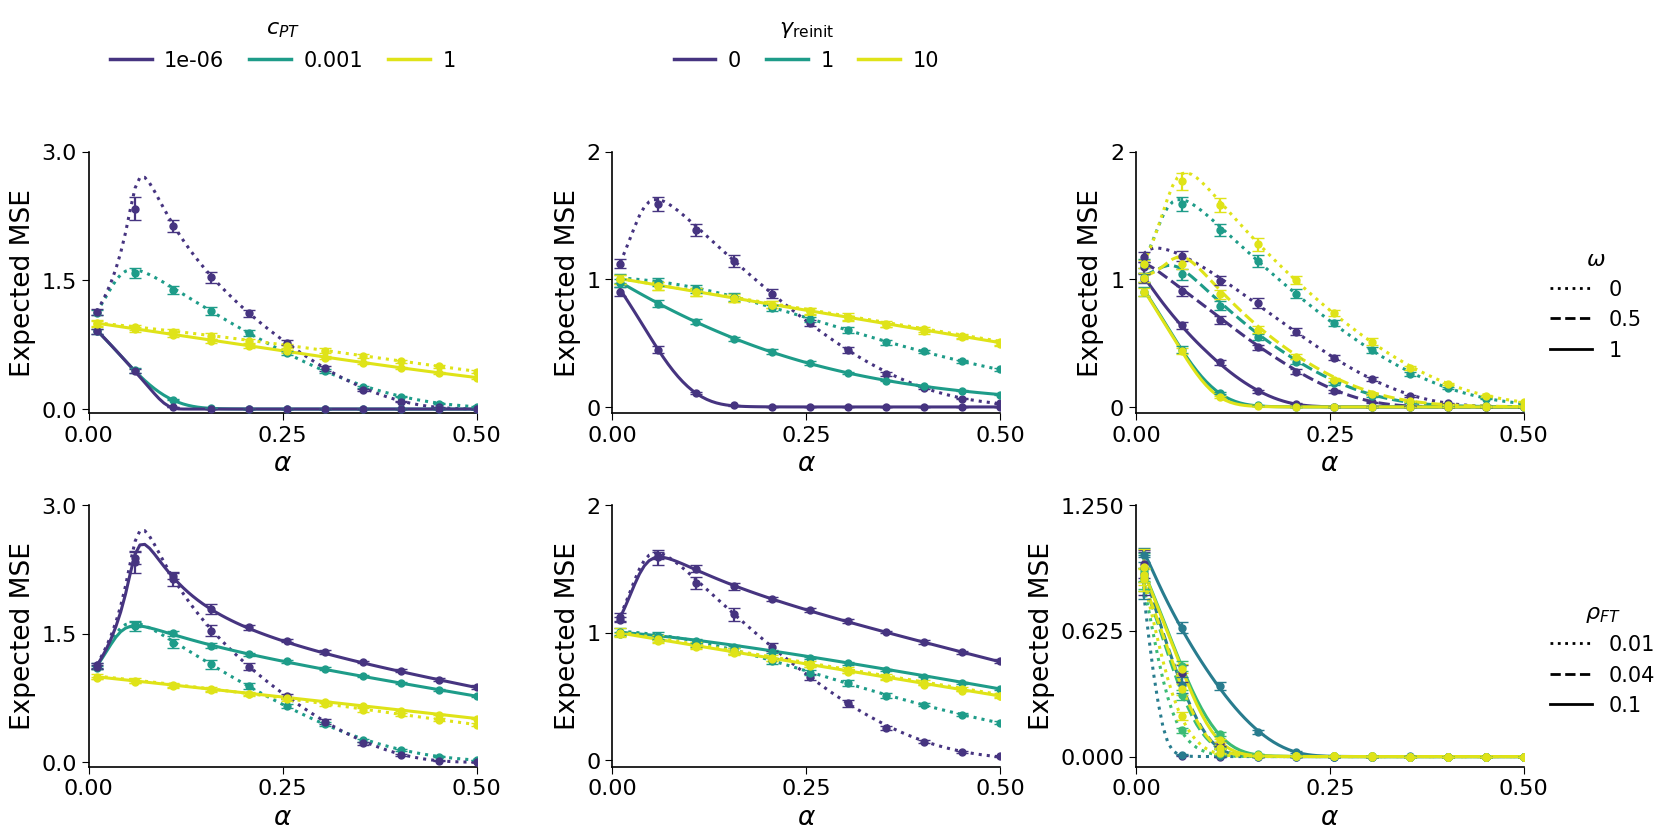

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

# -----------------------
# Global style (set ONCE)
# -----------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.labelsize": 19,
    "axes.titlesize": 19,
    "legend.fontsize": 15,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.linewidth": 1.2,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "errorbar.capsize": 4,

    "image.cmap": "viridis",
})

# -----------------------
# Helpers (shared)
# -----------------------
def ensure_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def make_combo_key(df, cols, float_round=12):
    d = df.copy()
    parts = []
    for c in cols:
        if c not in d.columns:
            continue
        s = d[c]
        if pd.api.types.is_numeric_dtype(s):
            s = pd.to_numeric(s, errors="coerce").round(float_round)
            parts.append(s.map(lambda x: "nan" if pd.isna(x) else f"{x:.{float_round}g}"))
        else:
            parts.append(s.astype(str))
    if not parts:
        return pd.Series([""] * len(d), index=d.index)
    out = parts[0].astype(str)
    for p in parts[1:]:
        out = out + "|" + p.astype(str)
    return out

def viridis_map(values, lo=0.15, hi=0.95, cmap_name="viridis"):
    vals = list(values)
    cmap = plt.get_cmap(cmap_name)
    return {
        v: cmap(lo + (hi - lo) * i / max(1, len(vals) - 1))
        for i, v in enumerate(vals)
    }

def add_top_legend(ax, handles, labels, title, ncol=None, y=1.22):
    if ncol is None:
        ncol = len(labels)
    return ax.legend(
        handles, labels, title=title, frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, y),
        bbox_transform=ax.transAxes,
        ncol=ncol,
        columnspacing=1.2,
        handletextpad=0.6,
    )

def format_axes(ax, ylim, yticks):
    ax.set_xlim(0.0, 0.5)
    ax.set_xticks([0.0, 0.25, 0.5])
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel("Expected MSE")
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())

def emp_ci95_stats(emp, group_cols, metric):
    s = (emp.groupby(group_cols, as_index=False)
           .agg(mean=(metric, "mean"), std=(metric, "std"), n=("seed", "nunique")))
    s["sem"] = s["std"] / np.sqrt(s["n"].clip(lower=1))
    s["ci95"] = 1.96 * s["sem"]
    return s

# -----------------------
# Load + numeric once (shared by all panels)
# Assumes rep_all_df and emp_all_df exist in your environment.
# -----------------------
rep_metric = "mse_best"
emp_metric = "final_param_mse"

num_cols_rep = ["alpha", rep_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit"]
num_cols_emp = ["alpha", emp_metric, "omega", "rho_pt", "rho_ft", "c_pt", "lambda_pt", "gamma_reinit", "seed"]

rep_all = ensure_numeric(rep_all_df.copy(), num_cols_rep)
emp_all = ensure_numeric(emp_all_df.copy(), num_cols_emp)

# -----------------------
# Panel A: vary c_PT (exp1; rho_pt=rho_ft=0.1; lambda=0; gamma=0; omega in {0,1})
# -----------------------
def panel_cpt(ax, rep_all, emp_all):
    EXPERIMENT = "exp1"
    RHO_PT = 0.1
    RHO_FT = 0.1
    omega_order = [0.0, 1.0]
    linestyle_map = {0.0: ":", 1.0: "-"}

    rep = rep_all.copy()
    emp = emp_all.copy()
    rep = rep[rep["experiment"] == EXPERIMENT].copy()
    emp = emp[emp["experiment"] == EXPERIMENT].copy()

    for df in (rep, emp):
        df.dropna(subset=["alpha", "omega"], inplace=True)

    rep = rep[np.isclose(rep["rho_pt"], RHO_PT)]
    emp = emp[np.isclose(emp["rho_pt"], RHO_PT)]
    rep = rep[np.isclose(rep["rho_ft"], RHO_FT)]
    emp = emp[np.isclose(emp["rho_ft"], RHO_FT)]
    rep = rep[np.isclose(rep["lambda_pt"], 0.0)]
    emp = emp[np.isclose(emp["lambda_pt"], 0.0)]
    rep = rep[np.isclose(rep["gamma_reinit"], 0.0)]
    emp = emp[np.isclose(emp["gamma_reinit"], 0.0)]
    rep = rep[rep["omega"].isin(omega_order)]
    emp = emp[emp["omega"].isin(omega_order)]

    base_cols = [c for c in ["rho_pt","rho_ft","c_pt","lambda_pt","gamma_reinit","ft_teacher_norm"]
                 if c in rep.columns and c in emp.columns]

    rep["base_key"] = make_combo_key(rep, base_cols)
    emp["base_key"] = make_combo_key(emp, base_cols)

    emp_stats = emp_ci95_stats(emp, ["omega","base_key","alpha"], emp_metric)

    tmp = emp.groupby("base_key", as_index=False).first()
    base_to_cpt = dict(zip(tmp["base_key"], tmp["c_pt"]))
    base_keys = sorted(emp_stats["base_key"].unique())
    ordered_base_keys = sorted(base_keys, key=lambda k: base_to_cpt[k])

    color_map = viridis_map(ordered_base_keys)

    # replica curves
    for om in omega_order:
        rep_o = rep[rep["omega"] == om]
        for bk, d in rep_o.groupby("base_key"):
            if bk not in color_map:
                continue
            d = d.sort_values("alpha")
            ax.plot(d["alpha"], d[rep_metric], color=color_map[bk],
                    linestyle=linestyle_map[om], linewidth=2.2, zorder=2)

    # empirical points
    for om in omega_order:
        s = emp_stats[emp_stats["omega"] == om]
        for bk, d in s.groupby("base_key"):
            if bk not in color_map:
                continue
            d = d.sort_values("alpha")
            ax.errorbar(d["alpha"], d["mean"], yerr=d["ci95"],
                        fmt="o", ms=5, capsize=4, elinewidth=1.6,
                        color=color_map[bk], zorder=3)

    format_axes(ax, ylim=(-0.05, 3.0), yticks=[0.0, 1.5, 3.0])

    # top legend: c_PT
    handles = [Line2D([0],[0], color=color_map[bk], lw=2.5) for bk in ordered_base_keys]
    labels = [f"{base_to_cpt[bk]:.3g}" for bk in ordered_base_keys]
    add_top_legend(ax, handles, labels, title=r"$c_{PT}$", ncol=len(labels), y=1.24)

# -----------------------
# Panel B: vary gamma_reinit (exp1; rho_pt=rho_ft=0.1; c_pt=1e-3; lambda=0; omega in {0,1})
# -----------------------
def panel_gamma(ax, rep_all, emp_all):
    EXPERIMENT = "exp1"
    RHO_PT = 0.1
    RHO_FT = 0.1
    C_PT = 1e-3
    LAMBDA = 0.0
    OMEGA_VALUES = [0.0, 1.0]
    ls_map = {0.0: ":", 1.0: "-"}

    rep = rep_all.copy()
    emp = emp_all.copy()
    rep = rep[rep["experiment"] == EXPERIMENT].copy()
    emp = emp[emp["experiment"] == EXPERIMENT].copy()

    def filt(df):
        df = df[np.isclose(df["rho_pt"], RHO_PT, atol=1e-9)].copy()
        df = df[np.isclose(df["rho_ft"], RHO_FT, atol=1e-9)].copy()
        df = df[np.isclose(df["c_pt"], C_PT, atol=1e-12)].copy()
        df = df[np.isclose(df["lambda_pt"], LAMBDA, atol=1e-12)].copy()
        df = df[df["omega"].isin(OMEGA_VALUES)].copy()
        df = df.dropna(subset=["alpha","omega","gamma_reinit"]).copy()
        return df

    rep = filt(rep)
    emp = filt(emp)

    gamma_vals = sorted(set(rep["gamma_reinit"].dropna().unique()) |
                        set(emp["gamma_reinit"].dropna().unique()))
    color_map = viridis_map(gamma_vals)

    rep["full_key"] = make_combo_key(rep, ["omega","gamma_reinit"])
    emp["full_key"] = make_combo_key(emp, ["omega","gamma_reinit"])
    rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

    emp_stats = emp_ci95_stats(emp, ["omega","gamma_reinit","alpha"], emp_metric)

    for g in gamma_vals:
        for om in OMEGA_VALUES:
            d = rep[(rep["gamma_reinit"] == g) & (rep["omega"] == om)]
            if d.empty: 
                continue
            d = d.sort_values("alpha")
            ax.plot(d["alpha"], d[rep_metric], color=color_map[g],
                    linestyle=ls_map[om], linewidth=2.2, zorder=2)

    for g in gamma_vals:
        for om in OMEGA_VALUES:
            d = emp_stats[(emp_stats["gamma_reinit"] == g) & (emp_stats["omega"] == om)]
            if d.empty:
                continue
            d = d.sort_values("alpha")
            ax.errorbar(d["alpha"], d["mean"], yerr=d["ci95"],
                        fmt="o", ms=5, capsize=4, elinewidth=1.6,
                        color=color_map[g], zorder=3)

    format_axes(ax, ylim=(-0.05, 2.0), yticks=[0.0, 1.0, 2.0])

    handles = [Line2D([0],[0], color=color_map[g], lw=2.5) for g in gamma_vals]
    labels  = [f"{g:g}" for g in gamma_vals]
    add_top_legend(ax, handles, labels, title=r"$\gamma_{\mathrm{reinit}}$", ncol=len(labels), y=1.24)

# -----------------------
# Panel C: vary lambda_pt (rho_pt=rho_ft=0.1; c_pt=1e-3; gamma=0; omega in {0,0.5,1})
# top legend lambda_pt; right legend omega
# -----------------------
def panel_lambda_omega(ax, rep_all, emp_all):
    RHO_PT = 0.1
    RHO_FT = 0.1
    C_PT   = 1e-3
    GAMMA  = 0.0
    OMEGA_VALUES = [0.0, 0.5, 1.0]
    ls_map = {0.0: ":", 0.5: "--", 1.0: "-"}
    LAMBDA_VALUES = [-1e-3, -0.99e-3, 0.0, 0.99e-3]
    EXCLUDE_LAMBDA_EQ_MINUS_C = True

    rep = rep_all.copy()
    emp = emp_all.copy()

    def filt(df):
        df = df[np.isclose(df["rho_pt"], RHO_PT, atol=1e-9)].copy()
        df = df[np.isclose(df["rho_ft"], RHO_FT, atol=1e-9)].copy()
        df = df[np.isclose(df["c_pt"], C_PT, atol=1e-12)].copy()
        df = df[np.isclose(df["gamma_reinit"], GAMMA, atol=1e-12)].copy()
        df = df[df["omega"].isin(OMEGA_VALUES)].copy()
        df = df[df["lambda_pt"].isin(LAMBDA_VALUES)].copy()
        df = df.dropna(subset=["alpha","omega","lambda_pt"]).copy()
        return df

    rep = filt(rep)
    emp = filt(emp)

    if EXCLUDE_LAMBDA_EQ_MINUS_C:
        rep = rep[~np.isclose(rep["lambda_pt"], -rep["c_pt"], atol=1e-12)].copy()
        emp = emp[~np.isclose(emp["lambda_pt"], -emp["c_pt"], atol=1e-12)].copy()

    lambda_vals = sorted(set(rep["lambda_pt"].dropna().unique()) | set(emp["lambda_pt"].dropna().unique()))
    omega_present = sorted(set(rep["omega"].dropna().unique()) | set(emp["omega"].dropna().unique()))
    omega_present = [om for om in OMEGA_VALUES if om in omega_present]

    color_map = viridis_map(lambda_vals)

    rep["full_key"] = make_combo_key(rep, ["omega","lambda_pt"])
    emp["full_key"] = make_combo_key(emp, ["omega","lambda_pt"])
    rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

    emp_stats = emp_ci95_stats(emp, ["omega","lambda_pt","alpha"], emp_metric)

    for lam in lambda_vals:
        for om in omega_present:
            d = rep[np.isclose(rep["lambda_pt"], lam, atol=1e-12) & np.isclose(rep["omega"], om, atol=1e-12)]
            if d.empty:
                continue
            d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
            ax.plot(d["alpha"].to_numpy(), d[rep_metric].to_numpy(),
                    color=color_map[lam], linestyle=ls_map.get(om, "-"),
                    linewidth=2.2, zorder=2)

    for lam in lambda_vals:
        for om in omega_present:
            d = emp_stats[np.isclose(emp_stats["lambda_pt"], lam, atol=1e-12) & np.isclose(emp_stats["omega"], om, atol=1e-12)]
            if d.empty:
                continue
            d = d.sort_values("alpha")
            ax.errorbar(d["alpha"].to_numpy(), d["mean"].to_numpy(),
                        yerr=d["ci95"].to_numpy(),
                        fmt="o", ms=5, capsize=4, elinewidth=1.6,
                        color=color_map[lam], zorder=3)

    format_axes(ax, ylim=(-0.05, 2.0), yticks=[0.0, 1.0, 2.0])

    # top legend: lambda
    lam_handles = [Line2D([0],[0], color=color_map[lam], lw=2.5) for lam in lambda_vals]
    lam_labels  = [f"{lam:.8g}" for lam in lambda_vals]
    add_top_legend(ax, lam_handles, lam_labels, title=r"$\lambda_{PT}$",
                   ncol=min(len(lam_labels), 4), y=1.24)

    # right legend: omega
    omega_handles = [Line2D([0],[0], color="black", lw=2, linestyle=ls_map.get(om, "-")) for om in omega_present]
    omega_labels  = [f"{om:g}" for om in omega_present]
    ax.legend(
        omega_handles, omega_labels, title=r"$\omega$", frameon=False,
        loc="upper left", bbox_to_anchor=(1.02, 0.70), bbox_transform=ax.transAxes
    )

# -----------------------
# Panel D: (your exp2 / omega=0 / vary rho_ft) — no legends in screenshot
# -----------------------
def panel_rhoft_cpt(ax, rep_all, emp_all):
    EXPERIMENT = "exp2"
    OMEGA = 0.0
    RHO_PT = 0.1
    RHO_FT_VALUES = [0.1, 0.9]
    ls_map = {0.1: ":", 0.9: "-"}  # rho_ft style

    rep = rep_all.copy()
    emp = emp_all.copy()
    if "experiment" in rep.columns:
        rep = rep[rep["experiment"] == EXPERIMENT].copy()
    if "experiment" in emp.columns:
        emp = emp[emp["experiment"] == EXPERIMENT].copy()

    def filt(df):
        df = df[np.isclose(df["omega"], OMEGA, atol=1e-9)].copy()
        df = df[np.isclose(df["rho_pt"], RHO_PT, atol=1e-9)].copy()
        df = df[df["rho_ft"].isin(RHO_FT_VALUES)].copy()
        df = df[np.isclose(df["lambda_pt"], 0.0, atol=1e-9)].copy()
        df = df[np.isclose(df["gamma_reinit"], 0.0, atol=1e-9)].copy()
        df = df.dropna(subset=["alpha","rho_ft"]).copy()
        return df

    rep = filt(rep)
    emp = filt(emp)

    # color by "base combo" excluding rho_ft (c_pt drives ordering)
    candidate_base_cols = ["omega","rho_pt","c_pt","lambda_pt","gamma_reinit","ft_teacher_norm"]
    base_cols = [c for c in candidate_base_cols if (c in rep.columns and c in emp.columns)]
    rep["base_key"] = make_combo_key(rep, base_cols)
    emp["base_key"] = make_combo_key(emp, base_cols)

    full_cols = base_cols + ["rho_ft"]
    rep["full_key"] = make_combo_key(rep, full_cols)
    emp["full_key"] = make_combo_key(emp, full_cols)

    rep = rep[rep["full_key"].isin(set(emp["full_key"].dropna().unique()))].copy()

    emp_stats = emp_ci95_stats(emp, ["rho_ft","base_key","full_key","alpha"], emp_metric)

    tmp = emp.dropna(subset=["base_key","c_pt"]).groupby("base_key", as_index=False).first()
    base_to_cpt = dict(zip(tmp["base_key"], tmp["c_pt"]))
    base_keys = sorted(emp_stats["base_key"].unique())
    ordered_base_keys = sorted(base_keys, key=lambda bk: float(base_to_cpt.get(bk, np.inf)))
    color_map = viridis_map(ordered_base_keys)

    for rf in RHO_FT_VALUES:
        d_rf = rep[np.isclose(rep["rho_ft"], rf, atol=1e-12)]
        for bk, d in d_rf.groupby("base_key"):
            if bk not in color_map:
                continue
            d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
            ax.plot(d["alpha"].to_numpy(), d[rep_metric].to_numpy(),
                    color=color_map[bk], linestyle=ls_map[rf], linewidth=2.2, zorder=2)

    for rf in RHO_FT_VALUES:
        s = emp_stats[np.isclose(emp_stats["rho_ft"], rf, atol=1e-12)]
        for bk, d in s.groupby("base_key"):
            if bk not in color_map:
                continue
            d = d.sort_values("alpha")
            ax.errorbar(d["alpha"].to_numpy(), d["mean"].to_numpy(), yerr=d["ci95"].to_numpy(),
                        fmt="o", ms=5, capsize=4, elinewidth=1.6,
                        color=color_map[bk], zorder=3)

    format_axes(ax, ylim=(-0.05, 3.0), yticks=[0.0, 1.5, 3.0])

# -----------------------
# Panel E: exp2 / omega=0 / vary rho_ft and gamma (no legends in screenshot)
# -----------------------
def panel_gamma_rhoft(ax, rep_all, emp_all):
    EXPERIMENT = "exp2"
    OMEGA = 0.0
    RHO_PT = 0.1
    RHO_FT_VALUES = [0.1, 0.9]
    C_PT = 1e-3
    LAMBDA = 0.0
    ls_map = {0.1: ":", 0.9: "-"}

    rep = rep_all.copy()
    emp = emp_all.copy()
    if "experiment" in rep.columns:
        rep = rep[rep["experiment"] == EXPERIMENT].copy()
    if "experiment" in emp.columns:
        emp = emp[emp["experiment"] == EXPERIMENT].copy()

    def filt(df):
        df = df[np.isclose(df["omega"], OMEGA, atol=1e-9)].copy()
        df = df[np.isclose(df["rho_pt"], RHO_PT, atol=1e-9)].copy()
        df = df[df["rho_ft"].isin(RHO_FT_VALUES)].copy()
        df = df[np.isclose(df["c_pt"], C_PT, atol=1e-12)].copy()
        df = df[np.isclose(df["lambda_pt"], LAMBDA, atol=1e-12)].copy()
        df = df.dropna(subset=["alpha","rho_ft","gamma_reinit"]).copy()
        return df

    rep = filt(rep)
    emp = filt(emp)

    gamma_vals = sorted(set(rep["gamma_reinit"].dropna().unique()) |
                        set(emp["gamma_reinit"].dropna().unique()))
    color_map = viridis_map(gamma_vals)

    rep["full_key"] = make_combo_key(rep, ["rho_ft","gamma_reinit"])
    emp["full_key"] = make_combo_key(emp, ["rho_ft","gamma_reinit"])
    rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

    emp_stats = emp_ci95_stats(emp, ["rho_ft","gamma_reinit","alpha"], emp_metric)

    for g in gamma_vals:
        for rf in RHO_FT_VALUES:
            d = rep[(rep["gamma_reinit"] == g) & (rep["rho_ft"] == rf)]
            if d.empty:
                continue
            d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
            ax.plot(d["alpha"].to_numpy(), d[rep_metric].to_numpy(),
                    color=color_map[g], linestyle=ls_map[rf], linewidth=2.2, zorder=2)

    for g in gamma_vals:
        for rf in RHO_FT_VALUES:
            d = emp_stats[(emp_stats["gamma_reinit"] == g) & (emp_stats["rho_ft"] == rf)]
            if d.empty:
                continue
            d = d.sort_values("alpha")
            ax.errorbar(d["alpha"].to_numpy(), d["mean"].to_numpy(), yerr=d["ci95"].to_numpy(),
                        fmt="o", ms=5, capsize=4, elinewidth=1.6,
                        color=color_map[g], zorder=3)

    format_axes(ax, ylim=(-0.05, 2.0), yticks=[0.0, 1.0, 2.0])

# -----------------------
# Panel F: omega=1 / vary rho_ft; color by lambda; right legend rho_pt (actually rho_ft in your code)
# -----------------------
def panel_lambda_rhoft(ax, rep_all, emp_all):
    OMEGA = 1.0
    RHO_PT = 0.1
    C_PT = 1e-3
    GAMMA = 0.0
    RHO_FT_KEEP = [0.01, 0.04, 0.1]
    ls_map = {0.01: ":", 0.04: "--", 0.1: "-"}

    rep = rep_all.copy()
    emp = emp_all.copy()

    def filt(df):
        df = df[np.isclose(df["omega"], OMEGA, atol=1e-9)].copy()
        df = df[np.isclose(df["rho_pt"], RHO_PT, atol=1e-9)].copy()
        df = df[np.isclose(df["c_pt"], C_PT, atol=1e-12)].copy()
        df = df[np.isclose(df["gamma_reinit"], GAMMA, atol=1e-12)].copy()
        df = df[df["rho_ft"].isin(RHO_FT_KEEP)].copy()
        df = df.dropna(subset=["alpha","rho_ft","lambda_pt"]).copy()
        return df

    rep = filt(rep)
    emp = filt(emp)

    # Exclude lambda == -c
    rep = rep[~np.isclose(rep["lambda_pt"], -rep["c_pt"], atol=1e-12)].copy()
    emp = emp[~np.isclose(emp["lambda_pt"], -emp["c_pt"], atol=1e-12)].copy()

    rho_ft_present = sorted(set(rep["rho_ft"].dropna().unique()) | set(emp["rho_ft"].dropna().unique()))
    lambda_vals = sorted(set(rep["lambda_pt"].dropna().unique()) | set(emp["lambda_pt"].dropna().unique()))
    color_map = viridis_map(lambda_vals)

    rep["full_key"] = make_combo_key(rep, ["rho_ft","lambda_pt"])
    emp["full_key"] = make_combo_key(emp, ["rho_ft","lambda_pt"])
    rep = rep[rep["full_key"].isin(emp["full_key"].dropna().unique())].copy()

    emp_stats = emp_ci95_stats(emp, ["rho_ft","lambda_pt","alpha"], emp_metric)

    for lam in lambda_vals:
        for rf in rho_ft_present:
            d = rep[np.isclose(rep["lambda_pt"], lam, atol=1e-12) & np.isclose(rep["rho_ft"], rf, atol=1e-12)]
            if d.empty:
                continue
            d = d.dropna(subset=["alpha", rep_metric]).sort_values("alpha")
            ax.plot(d["alpha"].to_numpy(), d[rep_metric].to_numpy(),
                    color=color_map[lam], linestyle=ls_map.get(rf, "-"),
                    linewidth=2.2, zorder=2)

    for lam in lambda_vals:
        for rf in rho_ft_present:
            d = emp_stats[np.isclose(emp_stats["lambda_pt"], lam, atol=1e-12) & np.isclose(emp_stats["rho_ft"], rf, atol=1e-12)]
            if d.empty:
                continue
            d = d.sort_values("alpha")
            ax.errorbar(d["alpha"].to_numpy(), d["mean"].to_numpy(), yerr=d["ci95"].to_numpy(),
                        fmt="o", ms=5, capsize=4, elinewidth=1.6,
                        color=color_map[lam], zorder=3)

    format_axes(ax, ylim=(-0.05, 1.25), yticks=[0.0, 0.625, 1.25])

    # right legend: rho_ft (your screenshot label might say rho_PT; adjust title if needed)
    rf_handles = [Line2D([0],[0], color="black", lw=2, linestyle=ls_map.get(rf, "-")) for rf in rho_ft_present]
    rf_labels  = [f"{rf:g}" for rf in rho_ft_present]
    ax.legend(
        rf_handles, rf_labels, title=r"$\rho_{FT}$", frameon=False,
        loc="upper left", bbox_to_anchor=(1.02, 0.70), bbox_transform=ax.transAxes
    )

# -----------------------
# Build the 2x3 figure
# -----------------------
fig, axes = plt.subplots(2, 3, figsize=(17.5, 7.5))

# spacing tuned so top-row per-axes legends fit + right-side legends fit
# fig.subplots_adjust(left=0.06, right=0.88, bottom=0.10, top=0.88, wspace=0.35, hspace=0.35)
fig.subplots_adjust(left=0.06, right=0.88, bottom=0.10, top=0.92, wspace=0.35, hspace=0.35)

panel_cpt(axes[0, 0], rep_all, emp_all)
panel_gamma(axes[0, 1], rep_all, emp_all)
panel_lambda_omega(axes[0, 2], rep_all, emp_all)

panel_rhoft_cpt(axes[1, 0], rep_all, emp_all)
panel_gamma_rhoft(axes[1, 1], rep_all, emp_all)
panel_lambda_rhoft(axes[1, 2], rep_all, emp_all)

plt.savefig("figure3.png", dpi=300)